## Import

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import textwrap
import math
import scipy
import scipy.stats as stats
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from datetime import datetime, timezone, timedelta
from collections import defaultdict

IBTrACS_path = 'IBTrACS.since1980.v04r01.nc'
IBTrACS_ds = xr.open_dataset(IBTrACS_path).load()

## Basins
basins = [b'EP', b'NA', b'NI', b'SA', b'SI', b'SP', b'WP']

# Auxiliary Methods

### Time conversion methods

In [2]:
'''
"to_datetime" converts a numpy datetime64 object (dtype of IBTrACS and CERES) to a python datetime object
(dtype of time in generated database).

Input:
  date - a np.datetime64 object
Output:
  DATE - a python datetime object
      
Source: https://gist.github.com/blaylockbk/1677b446bc741ee2db3e943ab7e4cabd?permalink_comment_id=3775327
'''
def to_datetime(date):
    timestamp = int((date - np.datetime64('1970-01-01T00:00:00'))
                 / np.timedelta64(1, 's'))
    return datetime.utcfromtimestamp(timestamp)


'''
"to_local_time" converts the IBTrACS time values for a storm (originally UTC time) into its local time.

Input:
  time_values - IBrACS time data
  longitude - IBTrACS storm longitude
Output:
  lt - local time data as numpy datetime64 object
  
'''
def to_local_time(time_values, longitude):
    datetimes = to_datetime(time_values)
    
    # convert to longitude west if needed
    if longitude > 180:
        longitude = longitude - 360
        lt = datetimes - timedelta(hours=int(longitude/15))
    else:
        lt = datetimes + timedelta(hours=int(longitude/15))
    
    return np.datetime64(lt)

### Print histograms

In [3]:
def get_categories(num_blocks):
    categories = []
    
    if num_blocks == 4:
        categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
    elif num_blocks == 8:
        categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']
    elif num_blocks == 12:
        categories = ['12am-2am', '2am-4am', '4am-6am', '6am-8am', '8am-10am', '10am-12pm', 
                      '12pm-2pm', '2pm-4pm', '4pm-6pm', '6pm-8pm', '8pm-10pm', '10pm-12am']
    elif num_blocks == 24:
        categories = ['12am', '1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am',
                      '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm']
    return categories

In [4]:
'''
"print_hist" creates the histogram visualization
'''

def print_hist(gen_times, years, num_blocks, thresh):
    n = 4
    categories = get_categories(num_blocks)
    if num_blocks == 24:
        n = 7
    
    fig, ax = plt.subplots(figsize=(n,n), dpi=300)
    
    ax.bar(categories, gen_times, color='gold')
    ax.set_xlabel('Local Time Bin (right incl.)')
    plt.setp(ax.get_xticklabels(), rotation=45)

    ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    ax.set_ylabel('Genesis Frequency')
    plt.suptitle(years)
    plt.title("Threshold: " + thresh + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
    plt.tight_layout()
    
    plt.show()

In [5]:
'''
"print_hist_err" creates the histogram visualization with error bars
'''

def print_hist_err(gen_means, errors, sample_size, title, num_blocks, n, pval):
    fig, ax = plt.subplots(figsize=(4,4), dpi=300)
    
    categories = get_categories(num_blocks)
    if num_blocks == 24:
        categories = [np.arange(24)]
    
    ax.bar(categories, gen_means, yerr=errors, capsize=3, color='skyblue', ecolor='black')
    ax.set_xlabel('Local Time Bin (right incl.)')
    plt.setp(ax.get_xticklabels(), rotation=45)
    ax.text(0.03, -0.35, 'mean p: ' + str(round(pval,3)), fontsize=8, color='gray', ha='left', va='top',transform=ax.transAxes)

    ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    plt.suptitle(title + ': N = ' + str(sample_size))
    plt.title('# TCs = ' + str(n), ha='center', y=1.0, fontsize=12, color='gray')
    ax.set_ylabel('Genesis Frequency')
    
    plt.show()

#### avg dI/dt histogram

In [6]:
def avg_dIdt_hist(dIdt, ltimes, title, subtitle):
    num_blocks = 4
    
    # ------------------------ Find Average ------------------------
    bin1 = []
    bin2 = []
    bin3 = []
    bin4 = []
    
    for j in range(len(dIdt)):
        block = sort_genesis(num_blocks, ltimes[j])
        if block == 0:
            bin1.append(dIdt[j])
        elif block == 1:
            bin2.append(dIdt[j])
        elif block == 2:
            bin3.append(dIdt[j])
        else:
            bin4.append(dIdt[j])
    
    bin1 = np.array(bin1)
    bin2 = np.array(bin2)
    bin3 = np.array(bin3)
    bin4 = np.array(bin4)
    
    dIdt_hist = np.array([bin1.mean(), bin2.mean(), bin3.mean(), bin4.mean()])
    errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])
    
    cat = get_categories(num_blocks)
    
    # --------------- Plot --------------
    fig, ax = plt.subplots(figsize=(4,4), dpi=150)
    ax.bar(cat, dIdt_hist, capsize=3, color='lightseagreen')
    #ax.invert_yaxis()
    ax.set_xlabel('LST bin')
    ax.set_ylabel('dI/dt (m/s / hr)')
    #ax.set_ylabel('dI/dt (mb/hr)')
    ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

    if basin == 'all':
        fig.suptitle(f"{title}")
    else:
        fig.suptitle(f"{title}")
    ax.set_title(f"{subtitle}", fontsize=9, color='gray')
    
    plt.setp(ax.get_xticklabels(), rotation=45)

#### 1x2 subplots

In [7]:
def dIdt_hist1x2(dIdt, ltimes, title, subtitle, weakening):
    num_blocks = 4

    bin1 = []
    bin2 = []
    bin3 = []
    bin4 = []
    
    for j in range(len(dIdt)):
        block = sort_genesis(num_blocks, ltimes[j])
        if block == 0:
            bin1.append(dIdt[j])
        elif block == 1:
            bin2.append(dIdt[j])
        elif block == 2:
            bin3.append(dIdt[j])
        else:
            bin4.append(dIdt[j])
    
    bin1 = np.array(bin1)
    bin2 = np.array(bin2)
    bin3 = np.array(bin3)
    bin4 = np.array(bin4)
    
    dIdt_hist = np.array([bin1.mean(), bin2.mean(), bin3.mean(), bin4.mean()])
    errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])
    
    cat = get_categories(num_blocks)

    # --------------------- Plot
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=150)
    
    cat = get_categories(num_blocks)
    
    for i in range(2):
        if i == 1:
            #axs[i].bar(cat, dIdt_hist, yerr=errors, capsize=3, color='paleturquoise')
            
            # Violin plot
            data = [bin1, bin2, bin3, bin4]
            pos = np.arange(num_blocks)
            axs[i].violinplot(data, pos, showmeans=False, showmedians=True)
        else:
            axs[i].bar(cat, dIdt_hist, capsize=3, color='lightseagreen')
        if weakening == 1:
            axs[i].invert_yaxis()
        axs[i].set_ylabel('dI/dt (m/s / hr)')
        axs[i].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
        axs[i].set_title(f"{subtitle}")
        axs[i].tick_params("x", rotation=45)
    
    fig.suptitle(f"{title}")

### Sorting method

In [8]:
def sort_genesis(num_blocks, genesis):
    block = 0
    # organize genesis hour into time block (right inclusive)
    
    if num_blocks == 8:
        # time blocks: '12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am'
        if genesis <= 6 and genesis > 3:
            block = 1;
        elif genesis <= 9 and genesis > 6:
            block = 2;
        elif genesis <= 12 and genesis > 9:
            block = 3;
        elif genesis <= 15 and genesis > 12:
            block = 4;
        elif genesis <= 18 and genesis > 15:
            block = 5;
        elif genesis <= 21 and genesis > 18:
            block = 6;
        elif genesis > 21 or genesis == 0:
            block = 7;

    elif num_blocks == 4:
        # time blocks: 12am-6am, 6am-12pm, 12pm-6pm, 6pm-12am
        if genesis <= 12 and genesis > 6:
            block = 1;
        elif genesis <= 18 and genesis > 12:
            block = 2;
        elif genesis > 18 or genesis == 0:
            block = 3;
    
    elif num_blocks == 12:
        # time blocks: '12am-2am', '2am-4am', '4am-6am', '6am-8am', '8am-10am', '10am-12pm', 
        #              '12pm-2pm', '2pm-4pm', '4pm-6pm', '6pm-8pm', '8pm-10pm', '10pm-12am'
        if genesis <= 4 and genesis > 2:
            block = 1;
        elif genesis <= 6 and genesis > 4:
            block = 2;
        elif genesis <= 8 and genesis > 6:
            block = 3;
        elif genesis <= 10 and genesis > 8:
            block = 4;
        elif genesis <= 12 and genesis > 10:
            block = 5;
        elif genesis <= 14 and genesis > 12:
            block = 6;
        elif genesis <= 16 and genesis > 14:
            block = 7;
        elif genesis <= 18 and genesis > 16:
            block = 8;
        elif genesis <= 20 and genesis > 18:
            block = 9;
        elif genesis <= 22 and genesis > 20:
            block = 10;
        elif genesis > 22 or genesis == 0:
            block = 11;
            
    return block

### Find p-value

In [9]:
'''
run Coarser Time Blocks -> gen_times is histogram values of genesis hours

T-tests are used to determine if there is significant deference between means of two variables and lets us know if they
belong to the same distribution.
'''
from scipy.stats import ttest_ind

def find_pvalue(gen_times):

    n = int(len(gen_times))
    
    # null hypothesis (randomly distributed genesis times)
    random_times = np.random.randint(24, size=n)
    
    x1 = random_times
    #x1 = normalize(x1)
    
    # observation data
    x2 = gen_times
    
    assert len(x1) == len(x2)
    
    # t-test
    res = ttest_ind(x1, x2)
    
    return res.pvalue

In [10]:
'''
Performs two-sample Kolmogorov-Smirnov test (two-sided)
Source --> https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html
'''
from scipy.stats import ks_2samp

def ks2samp_pvalue(gen_times, maxval):

    n = int(len(gen_times))
    
    # null hypothesis (randomly distributed genesis times)
    random_times = np.random.randint(24, size=n)
    #random_times = np.random.rand(n) * (maxval+1)
    
    x1 = random_times
    #x1 = normalize(x1)
    
    # observation data
    x2 = gen_times
    
    assert len(x1) == len(x2)
    
    # ks test
    res = ks_2samp(x1, x2)
    
    return res.pvalue

In [11]:
'''
Performs two-sample Kolmogorov-Smirnov test (two-sided)
Source --> https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html
'''
from scipy.stats import kstest

def kstest_pvalue(gen_times):

    n = int(len(gen_times))
    
    # null hypothesis (randomly distributed genesis times)
    random_times = np.random.randint(24, size=n)
    
    x1 = random_times
    #x1 = normalize(x1)
    
    # observation data
    x2 = gen_times
    
    assert len(x1) == len(x2)
    
    # ks test
    res = kstest(x1, x2)
    
    return res.pvalue

## Generate datasets

### Generate observation genesis dataset

In [12]:
'''
Returns gen_times (list of genesis hours for TCs in a certain dataset).
Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
All TCs whose genesis record is the first record itself are removed.
'''

def generate_data(threshold_ms, sindices, basin):
    threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)
    
    gen_times = []
    
    count = 0

    if basin != 'all':
        basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = IBTrACS_ds
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        count += 1

        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        #longitude = storm_data['lon'][0]
        
        # drop nan time values
        mask = ~np.isnan(storm_data['time'])
        time_clean = storm_data['time'][mask]
        first_record = time_clean[0]

        # ---- Find Genesis Time
        # query storm data once it turns into TC
        TSdata = storm_data.where(storm_data['wmo_wind'] >= threshold_kts, drop=True)
    
        # find storm longitude for local time conversion
        if np.isnan(TSdata['lon']).all():
            continue
        genesis = TSdata['time'][0]

        if first_record != genesis:
            # convert to hour of local time
            longitude = TSdata['lon'][0]
            local_times = [to_local_time(time, longitude) for time in TSdata['time']]
            hours = [to_datetime(time).hour for time in local_times]
        
            # find genesis time
            gen_hour = hours[0]

            # append to gen_times
            gen_times = np.append(gen_times, gen_hour)
    
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")
    
    return gen_times

In [13]:
def generate_data_wo_lag(threshold_ms, sindices, basin):
    threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)
    
    gen_times = []
    
    count = 0

    if basin != 'all':
        basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = IBTrACS_ds
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        count += 1
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        TSdata = basin_ds.isel(storm=storm_index) # first record
    
        # drop nan time values
        mask = ~np.isnan(TSdata['time'])
        time_clean = TSdata['time'][mask]
        
        # find storm longitude for local time conversion
        if np.isnan(TSdata['lon']).all():
            continue
        longitude = TSdata['lon'][0]
        
        # convert to hour of local time
        local_times = [to_local_time(time, longitude) for time in time_clean]
    
        # find genesis time
        first_record = to_datetime(local_times[0])
    
        # ---- Find Genesis Time
        # query storm data once it turns into TC
        TCdata = TSdata.where(TSdata['wmo_wind'] >= threshold_kts, drop=True)
    
        # find storm longitude for local time conversion
        if np.isnan(TCdata['lon']).all():
            continue
            
        longitude = TCdata['lon'][0]
    
        # convert to hour of local time
        local_times = [to_local_time(time, longitude) for time in TCdata['time']]
    
        # find genesis time
        genesis = to_datetime(local_times[0])
    
        lagtime = (genesis - first_record).total_seconds() // 3600
    
        if lagtime > 12:
            gen_times = np.append(gen_times, genesis.hour)
    
        if count % 1000 == 0:
            print(count, '/4787 searched through')
    
    return gen_times

### Generate dI/dt dataset

In [ ]:
'''
Returns dIdt (list of delta intensities between each 3 hour interval) and ltimes (list of hours associated with each delta).
Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
'''
from astropy.stats import sigma_clip

def generate_intensities(sindices, basin, sigma, nature, duration_thresh):
    dIdt = [] # dt = 3 hours
    Ivals = []
    ltimes = [] # local times associated with each dIdt point
    
    count = 0
    
    # dates
    year_ds = IBTrACS_ds.where((IBTrACS_ds['storm'] >= min(sindices)) & (IBTrACS_ds['storm'] <= max(sindices)), drop=True)
    
    if basin != 'all':
        basin_ds = year_ds.where((year_ds['basin'] == basin), drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = year_ds
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        
        # find intensities
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        
        # find times
        time_clean = storm_data['time'][mask].values
        if len(time_clean) == 0:
            continue
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]

        # filter out storms lasting under X hours
        storm_duration = (times[len(times)-1] - times[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
        
        # find dI/dt
        assert len(intensities) == len(times)
        for i in range(len(intensities)-1):
            #print("i:",i)
            if storm_data['nature'][mask].values[i] != nature: # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i]).total_seconds()/3600
            dIdt.append((intensities[i+1]-intensities[i])/delta)
            Ivals.append(intensities[i+1])
            ltimes.append(times[i+1].hour) # basically remove first data point from times

        if len(dIdt) == 0:
            continue
            
        # filter out weakening accelerations
        max_idx = np.argmax(Ivals)
        dIdt = dIdt[:max_idx+1]
        ltimes = ltimes[:max_idx+1]
        Ivals = Ivals[:max_idx+1]

        count += 1
        
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    # sigma clipping returns clipped ndarray, lower threshold, upper threshold
    if sigma != 0:
        boolean_mask = sigma_clip(dIdt, sigma=sigma, maxiters=5, masked=True).mask
        mask  = [index for (index, item) in enumerate(boolean_mask) if item == False]

        dIdt = [dIdt[index] for index in mask]
        ltimes = [ltimes[index] for index in mask]
        Ivals = [Ivals[index] for index in mask]
    
    # convert to m/s (IBTrACS wind speed is in kts)
    dIdt = np.array(dIdt)/2.2369
    ltimes = np.array(ltimes)
    Ivals = np.array(Ivals)/2.2369
    
    return dIdt, ltimes, Ivals, count

### Generate dp/dt dataset

In [ ]:
'''
Returns dIdt (list of delta intensities between each 3 hour interval) and ltimes (list of hours associated with each delta).
Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
'''
from astropy.stats import sigma_clip

def generate_dpdt(sindices, basin, sigma, nature):
    dIdt = [] # dt = 3 hours
    Ivals = []
    ltimes = [] # local times associated with each dIdt point
    
    count = 0
    
    # dates
    year_ds = IBTrACS_ds.where((IBTrACS_ds['storm'] >= min(sindices)) & (IBTrACS_ds['storm'] <= max(sindices)), drop=True)
    
    if basin != 'all':
        basin_ds = year_ds.where((year_ds['basin'] == basin), drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = year_ds
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        count += 1
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        
        # find intensities
        mask = ~np.isnan(storm_data['wmo_pres'])
        intensities = storm_data['wmo_pres'][mask].values
        
        # find times
        time_clean = storm_data['time'][mask].values
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]
        
        # find dI/dt
        assert len(intensities) == len(times)
        for i in range(1,len(intensities)-1):
            #print("i:",i)
            if storm_data['nature'][mask].values[i] != nature: # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i-1]).total_seconds()/3600
            if delta < 0:
                print("ahead:", times[i+1])
                print("behind:", times[i-1])
                print("delta:",delta)
                print("times:")
                print(times)
            dIdt.append((intensities[i+1]-intensities[i-1])/delta)
            Ivals.append(intensities[i+1])
            ltimes.append(times[i+1].hour) # basically remove first data point from times
    
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    # sigma clipping returns clipped ndarray, lower threshold, upper threshold
    if sigma != 0:
        boolean_mask = sigma_clip(dIdt, sigma=sigma, maxiters=5, masked=True).mask
        mask  = [index for (index, item) in enumerate(boolean_mask) if item == False]

        dIdt = [dIdt[index] for index in mask]
        ltimes = [ltimes[index] for index in mask]
        Ivals = [Ivals[index] for index in mask]
    
    # convert to m/s (IBTrACS wind speed is in kts)
    dIdt = np.array(dIdt)/2.2369
    ltimes = np.array(ltimes)
    Ivals = np.array(Ivals)/2.2369
    
    return dIdt, ltimes, Ivals, count

### Generate max dI/dt

In [16]:
'''
Returns max dIdt and local time of max acceleration for each storm.
'''

def generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type):
    if threshold != "none":
        thresholds = tuple([int(bound) for bound in threshold.split('-')])
        threshold_kts = [threshold_ms*2.2369 for threshold_ms in thresholds] # convert to kts aka mph (IBTrACS unit)
    
    maxdIdt = []
    maxtimes = []
    maxIvals = []
    
    count = 0
    
    # dates
    year_ds = IBTrACS_ds.where((IBTrACS_ds['storm'] >= min(sindices)) & (IBTrACS_ds['storm'] <= max(sindices)), drop=True)
    
    if basin != 'all':
        basin_ds = year_ds.where((year_ds['basin'] == basin), drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = year_ds
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)

    # testing
    intensitiesD = dict()
    bla = []

    # append genesis times to histogram
    for storm_index in sindices:
        dIdt = [] # dt = 3 hours
        ltimes = [] # local times associated with each dIdt point
        Ivals = [] # windspeed @time
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
        
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue

        # find intensities
        if threshold != "none":
            storm_data['wmo_wind'] = storm_data['wmo_wind'].where(
                (storm_data['wmo_wind'] >= threshold_kts[0]) &
                (storm_data['wmo_wind'] < threshold_kts[1]), drop=False
            )
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        if intensities.size == 0:  # don't count storms that are not within intensity threshold
            continue
        intensitiesD[storm_index] = intensities
        
        # find times
        time_clean = storm_data['time'][mask].values
        if len(time_clean) == 0:
            continue
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]

        # filter out storms lasting under X hours
        storm_duration = (times[len(times)-1] - times[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
        
        count += 1
        bla.append(storm_index)
        
        # find dI/dt
        assert len(intensities) == len(times)
        for i in range(1,len(intensities)-1):
            if (storm_data['nature'][mask].values[i] != nature): # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i-1]).total_seconds()/3600
            if delta < 0:
                print("ahead:", times[i+1])
                print("behind:", times[i-1])
                print("delta:",delta)
                print("times:")
                print(times)
            dIdt.append((intensities[i+1]-intensities[i-1])/delta)
            ltimes.append(times[i+1].hour) # basically remove first data point from times
            Ivals.append(intensities[i+1])

        if len(dIdt) != 0:
            # convert to m/s (IBTrACS wind speed is in kts)
            dIdt = np.array(dIdt)/2.2369
            ltimes = np.array(ltimes)
            Ivals = np.array(Ivals)/2.2369

            if accel_type == 'max':
                idx = np.argmax(dIdt)
            elif accel_type == 'min':
                idx = np.argmin(dIdt)
            maxdIdt.append(dIdt[idx])
            maxtimes.append(ltimes[idx])
            maxIvals.append(Ivals[idx])
        
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    return maxdIdt, maxtimes, maxIvals, count

### Generate local maxes dI/dt

In [125]:
'''
Returns local max dIdt and local time of max acceleration for each storm.
'''

def generate_localmaxes(sindices, basin, nature, threshold, duration_thresh, accel_type, segment_threshs):
    if threshold != "none":
        thresholds = tuple([int(bound) for bound in threshold.split('-')])
        threshold_kts = [threshold_ms*2.2369 for threshold_ms in thresholds] # convert to kts aka mph (IBTrACS unit)

    maxdIdt = []
    maxtimes = []
    maxIvals = []
    count = 0
    
    # dates
    year_ds = IBTrACS_ds.where((IBTrACS_ds['storm'] >= min(sindices)) & (IBTrACS_ds['storm'] <= max(sindices)), drop=True)
    
    if basin != 'all':
        basin_ds = year_ds.where((year_ds['basin'] == basin), drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = year_ds
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)

    # testing
    intensitiesD = dict()
    bla = []

    # append genesis times to histogram
    for storm_index in sindices:
        dIdt = [] # dt = 3 hours
        ltimes = [] # local times associated with each dIdt point
        Ivals = [] # windspeed @time
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
        
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue

        # find intensities
        if threshold != "none":
            storm_data['wmo_wind'] = storm_data['wmo_wind'].where(
                (storm_data['wmo_wind'] >= threshold_kts[0]) &
                (storm_data['wmo_wind'] < threshold_kts[1]), drop=False
            )
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        if intensities.size == 0:  # don't count storms that are not within intensity threshold
            continue
        intensitiesD[storm_index] = intensities
        
        # find times
        time_clean = storm_data['time'][mask].values
        if len(time_clean) == 0:
            continue
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]

        # filter out storms lasting under X hours
        storm_duration = (times[len(times)-1] - times[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
        
        count += 1
        bla.append(storm_index)
        
        # find dI/dt
        assert len(intensities) == len(times)
        for i in range(1,len(intensities)-1):
            if (storm_data['nature'][mask].values[i] != nature): # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i-1]).total_seconds()/3600
            dIdt.append((intensities[i+1]-intensities[i-1])/delta)
            ltimes.append(times[i+1].hour) # basically remove first data point from times
            Ivals.append(intensities[i+1])

        if len(dIdt) == 0:
            continue
        
        # find local maxes
        dIdt = np.array(dIdt)/2.2369 # convert to m/s (IBTrACS wind speed is in kts)
        ltimes = np.array(ltimes)
        Ivals = np.array(Ivals)/2.2369

        if accel_type == 'max':
            if segment_threshs == 'default':
                maxpeakIndices = get_local_maxes(dIdt, Ivals)
            elif segment_threshs != 'default':
                cutoffs = tuple(map(int, segment_threshs.split(',')))
                maxpeakIndices = get_local_max_custom(dIdt, Ivals, cutoffs)
            for idx in maxpeakIndices:
                if idx == -100:
                    continue
                #print(f"appended {dIdt[idx]}")
                maxdIdt.append(dIdt[idx])
                maxtimes.append(ltimes[idx])
                maxIvals.append(Ivals[idx])
        #elif accel_type == 'min':
        
        if maxpeakIndices == -100:
            continue
        
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    return maxdIdt, maxtimes, maxIvals, count

In [18]:
def get_local_maxes(inputArray, splittingArray):
    maxpeakIndices = []
    # find bordering indices of intensity categories
    i = 0
    while splittingArray[i] < 17 and i < len(splittingArray)-1:
        i += 1
    borderLow = i
    
    # check if storm never reaches 17 m/s
    if borderLow == len(splittingArray)-1:
        maxpeakIndices.append(-100)
        return maxpeakIndices
        
    while splittingArray[i] >= 17 and splittingArray[i] < 33  and i < len(splittingArray)-1:
        i += 1
    borderMid = i

    while splittingArray[i] >= 33  and i < len(splittingArray)-1:
        i += 1
    
    borderHi = i

    maxpeakIndices.append(get_peaks(inputArray, borderLow, borderMid))
    
    if borderMid != borderHi:
        maxpeakIndices.append(get_peaks(inputArray, borderMid, borderHi))

    return maxpeakIndices

In [ ]:
def get_local_max_custom(inputArray, splittingArray, speed_cutoffs):
    maxpeakIndices = []
    borders = []
    
    # find bordering indices of intensity categories
    i = 0

    # initial border
    while splittingArray[i] < speed_cutoffs[0] and i < len(splittingArray)-1:
            i += 1
    
    borders.append(i)

    if i == len(splittingArray)-1: # check if storm never reaches cutoff m/s
        return maxpeakIndices

    # find remaining borders
    for j in range(1,len(speed_cutoffs)-2):
        while splittingArray[i] >= speed_cutoffs[j-1] and splittingArray[i] < speed_cutoffs[j]  and i < len(splittingArray)-1:
            i += 1
        borders.append(i)

        if borders[-1] == len(splittingArray)-1: # check if storm never reaches cutoff m/s
            return maxpeakIndices
    
    # last border
    while splittingArray[i] >= speed_cutoffs[j+1]  and i < len(splittingArray)-1:
        i += 1
        
        borders.append(i)

    #print(f"borders: {borders}")
    # get max peaks in each segment
    for j in range(len(borders)-2):
        maxpeakIndices.append(get_peaks(inputArray, borders[j], borders[j+1]))
    
    if borders[-2] != borders[-1]:
        maxpeakIndices.append(get_peaks(inputArray, borders[-2], borders[-1]))

    #print(f"maxpeakIndices: {maxpeakIndices}")
    return maxpeakIndices

In [87]:
def get_peaks(inputArray, borderLeft, borderRight):

    if borderRight == len(inputArray)-1:
        segment = inputArray[borderLeft:borderRight]
    else:
        segment = inputArray[borderLeft:borderRight+1]
    
    # find peaks within segment
    peakIdx, ____ = find_peaks(segment)
    
    peakValues = np.array([segment[idx] for idx in peakIdx])
    if peakValues.size != 0:
        tempIdx = np.argmax(peakValues)
        maxpeakIdx = borderLeft + peakIdx[tempIdx]
    else: # if no peak exists within segment, return overall max?
        maxpeakIdx = borderLeft + np.argmax(segment)
        
    return maxpeakIdx

### Normalize

In [20]:
def normalize(data):
  return (data - data.min()) / (data.max() - data.min())

# Wind Acceleration

In [ ]:
# generate dI/dt
sindices = np.arange(1,4787)
basin = b'NI'
nature = b'DS'
sigma = 0

dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)
#plt.hist(dIdt, bins=50)
#plt.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)

## Histogram of dI/dt values

In [ ]:
# Sort
num_blocks = 4
dIdt_hist = np.zeros(num_blocks)
C1 = -5
C2 = 5

for j in range(len(dIdt)):
    if dIdt[j] >= C2 or dIdt[j] <= C1:
        continue
    block = sort_genesis(num_blocks, ltimes[j])
    dIdt_hist[block] += 1

print_hist(dIdt_hist, 'dI/dt EP Basin', num_blocks, str(C1) + ' to ' + str(C2))

### 1x4 subplots

plot # 1
plot # 2
plot # 3
plot # 4


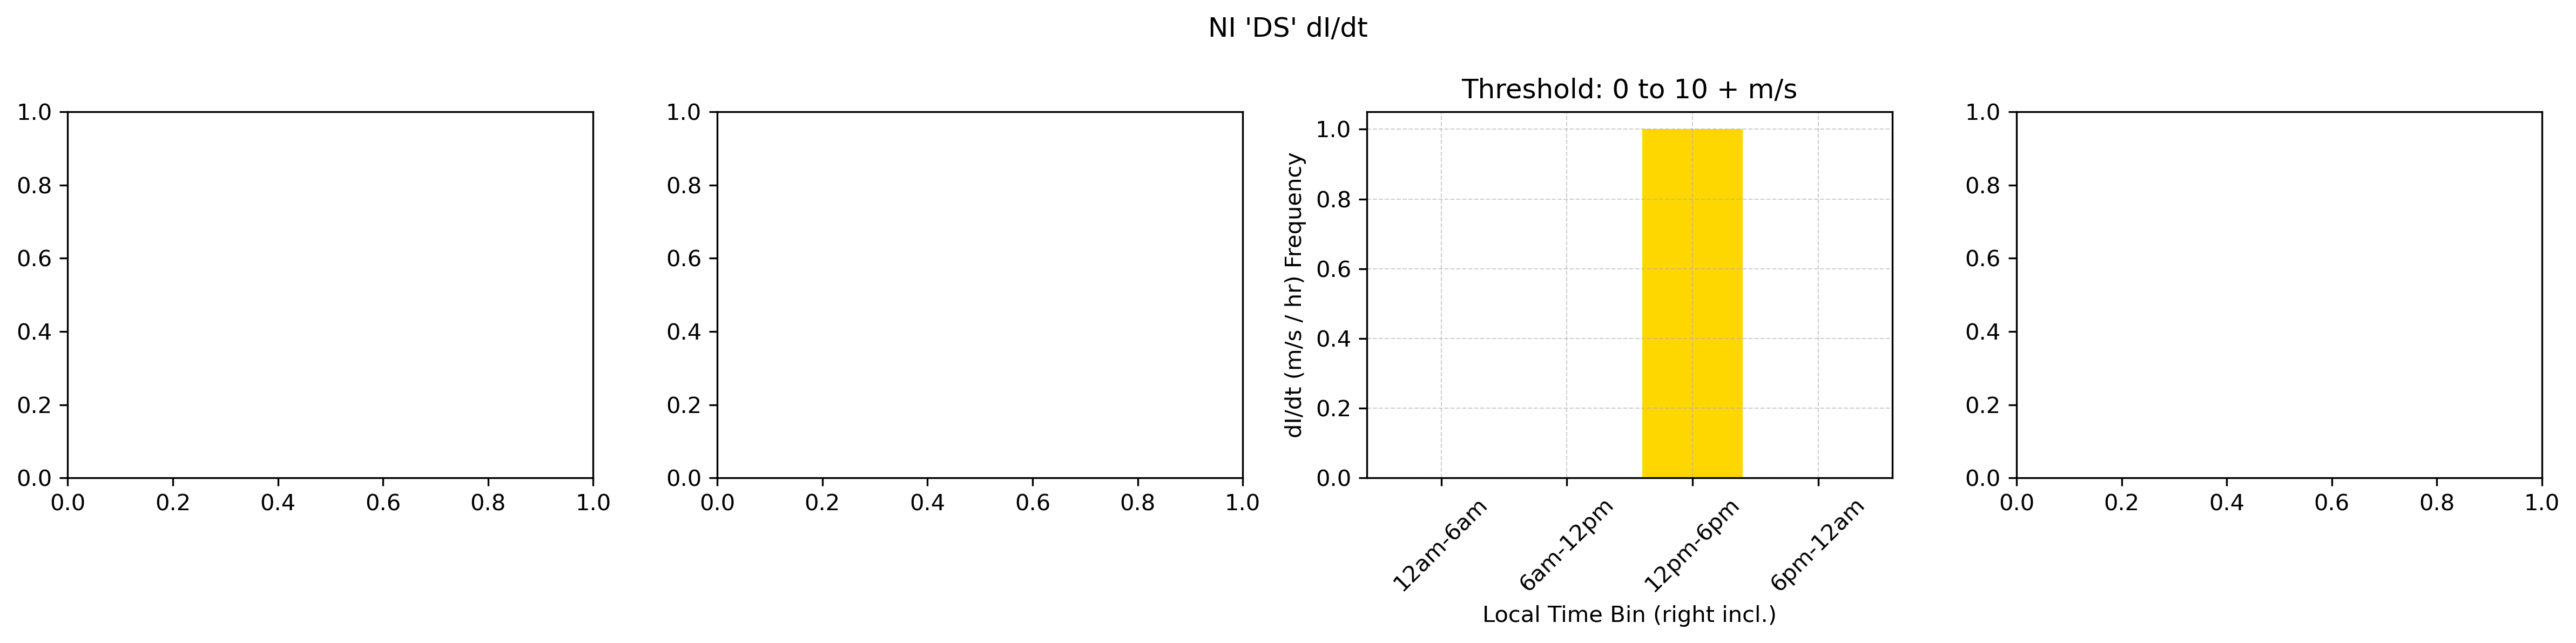

In [41]:
# print all 10 m/s ranges
num_blocks = 4

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16,4), dpi=300)

for i in range(4):
    print("plot #", i+1)
    
    C1 = -20 + i*10
    C2 = -10 + i*10
    
    dIdt_hist = np.zeros(num_blocks)
    
    for j in range(len(dIdt)):
        if dIdt[j] > C2 or dIdt[j] <= C1:
            continue
        block = sort_genesis(num_blocks, ltimes[j])
        dIdt_hist[block] += 1
    
        # print histogram
        categories = get_categories(num_blocks)
        axs[i].bar(categories, dIdt_hist, color='gold')
        axs[i].tick_params("x", rotation=45)
    
        # set labels & grid
        axs[i].set_xlabel('Local Time Bin (right incl.)')
        axs[i].grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
        axs[i].set_ylabel('dI/dt (m/s / hr) Frequency')
        axs[i].set_title(f"Threshold: {C1} to {C2} + m/s")

plt.suptitle(f"{basin.decode('utf-8')} '{nature.decode('utf-8')}' dI/dt")
#plt.suptitle("Threshold: " + str(C1) + ' to ' + str(C2) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
plt.tight_layout()

plt.show()

## dI/dt per time bin

### Average per time bin

In [243]:
# ----------------- Generate Database -------------------------
num_blocks = 4
sindices = np.arange(0,4787)
basin = 'all'
sigma = 0
nature = b'TS'
duration = 24

dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature, duration)
#dIdt, ltimes, Ivals, count = generate_dpdt(sindices, basin, sigma, nature)

# ------------------------ Find Average ------------------------
bin1 = []
bin2 = []
bin3 = []
bin4 = []

for j in range(len(dIdt)):
    block = sort_genesis(num_blocks, ltimes[j])
    if block == 0:
        bin1.append(dIdt[j])
    elif block == 1:
        bin2.append(dIdt[j])
    elif block == 2:
        bin3.append(dIdt[j])
    else:
        bin4.append(dIdt[j])

bin1 = np.array(bin1)
bin2 = np.array(bin2)
bin3 = np.array(bin3)
bin4 = np.array(bin4)

dIdt_hist = np.array([bin1.mean(), bin2.mean(), bin3.mean(), bin4.mean()])
errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])

cat = get_categories(num_blocks)

1000 / 4787 databases loaded
2000 / 4787 databases loaded
3000 / 4787 databases loaded
4000 / 4787 databases loaded


[None, None, None, None]

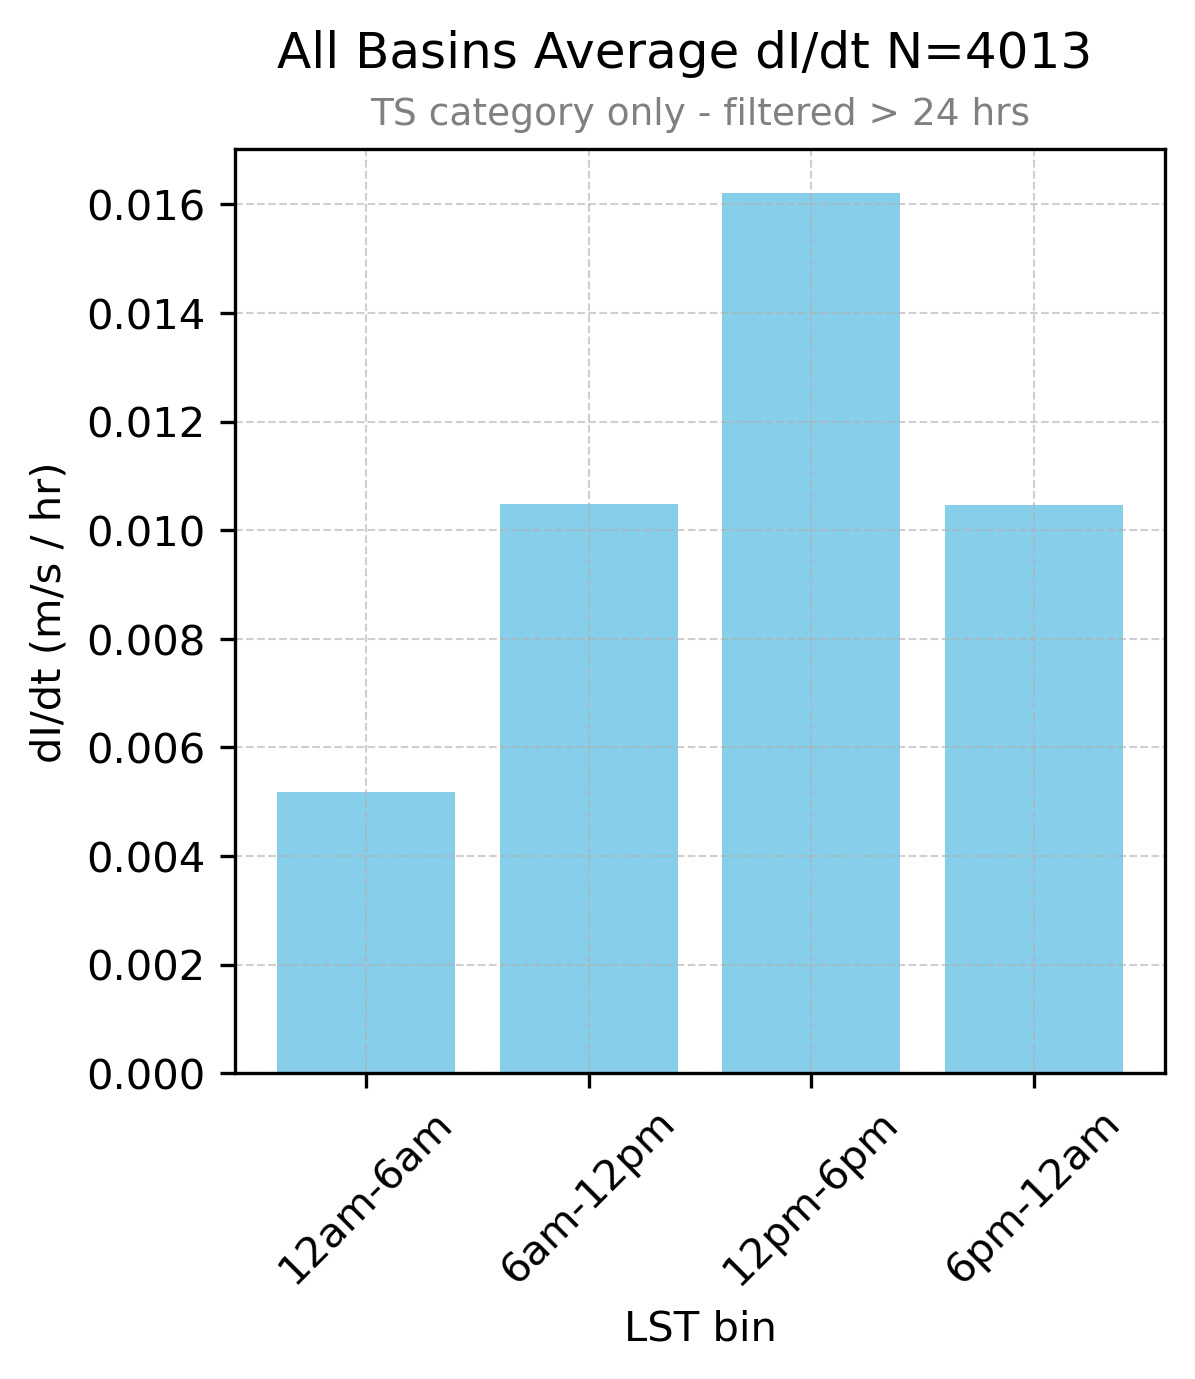

In [244]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)
ax.bar(cat, dIdt_hist, capsize=3, color='skyblue')
#ax.invert_yaxis()
ax.set_xlabel('LST bin')
ax.set_ylabel('dI/dt (m/s / hr)')
#ax.set_ylabel('dI/dt (mb/hr)')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

if basin == 'all':
    fig.suptitle(f"All Basins Average dI/dt N={count}")
else:
    fig.suptitle(f"{basin.decode('utf-8')} Average dI/dt N={count}")
ax.set_title(f"{nature.decode('utf-8')} category only - filtered > {duration} hrs", fontsize=9, color='gray')

plt.setp(ax.get_xticklabels(), rotation=45)
#n_string = 'bin1 N=' + str(len(bin1)) + '\nbin2 N=' + str(len(bin2)) + '\nbin3 N=' + str(len(bin3)) + '\nbin4 N=' + str(len(bin4))
#ax.text(0, -0.35, n_string, fontsize=8, color='gray', ha='left', va='top',transform=ax.transAxes)

#### 1x2 subplots

In [211]:
# ------------------------ Find Average ------------------------
bin1 = []
bin2 = []
bin3 = []
bin4 = []

for j in range(len(dIdt)):
    block = sort_genesis(num_blocks, ltimes[j])
    if block == 0:
        bin1.append(dIdt[j])
    elif block == 1:
        bin2.append(dIdt[j])
    elif block == 2:
        bin3.append(dIdt[j])
    else:
        bin4.append(dIdt[j])

bin1 = np.array(bin1)
bin2 = np.array(bin2)
bin3 = np.array(bin3)
bin4 = np.array(bin4)

dIdt_hist = np.array([bin1.mean(), bin2.mean(), bin3.mean(), bin4.mean()])
errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])

cat = get_categories(num_blocks)

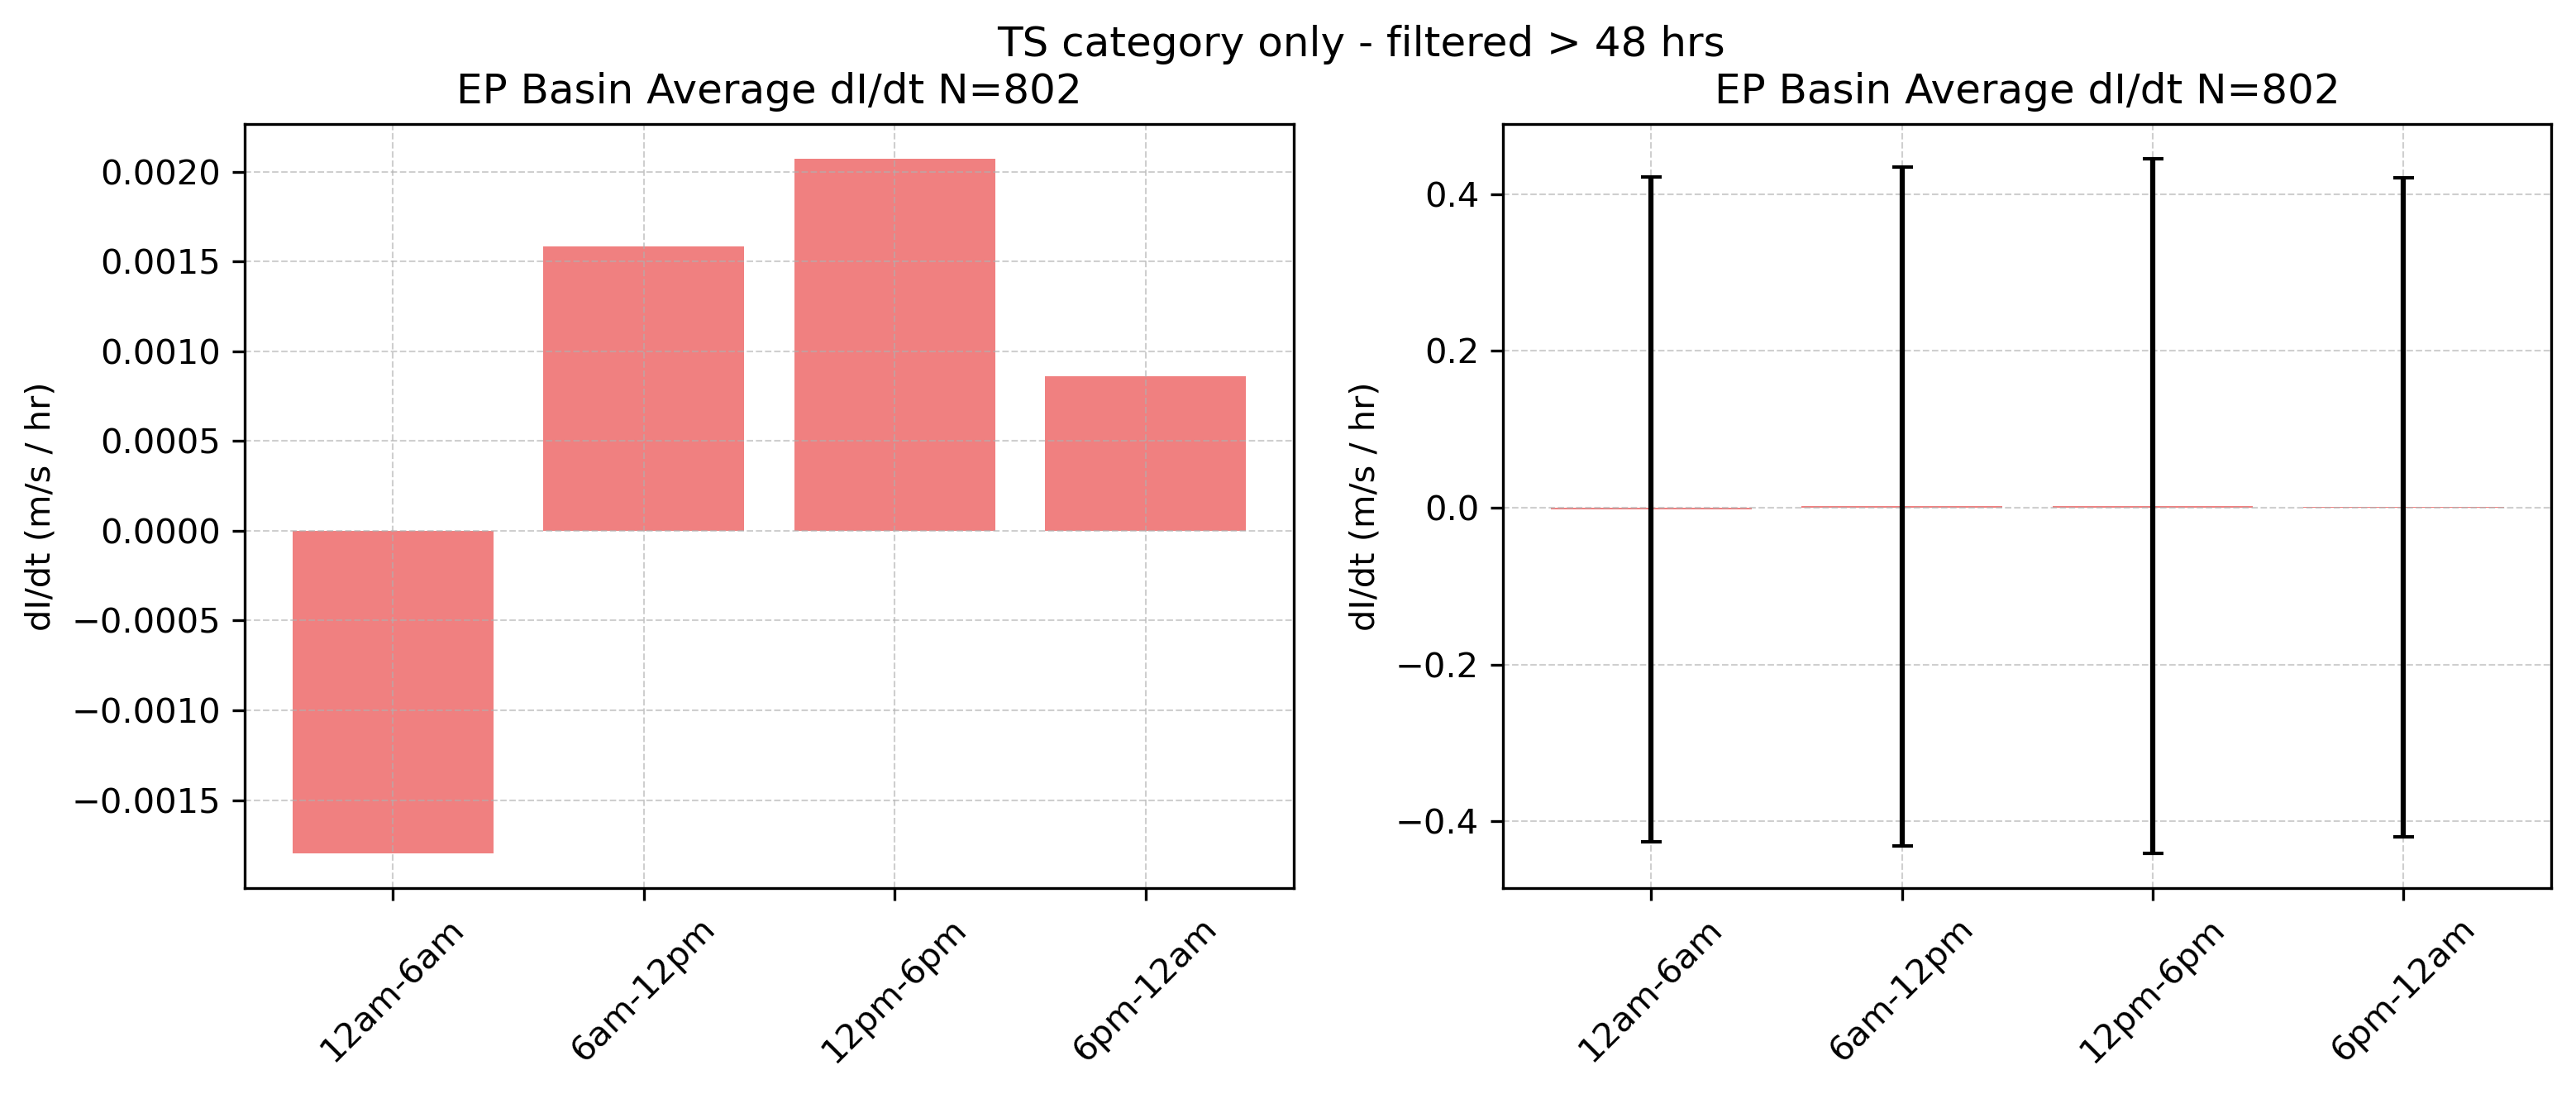

In [212]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=300)

for i in range(2):
    if i == 1:
        axs[i].bar(cat, dIdt_hist, yerr=errors, capsize=3, color='lightcoral')
    else:
        axs[i].bar(cat, dIdt_hist, capsize=3, color='lightcoral')
    axs[i].set_ylabel('dI/dt (m/s / hr)')
    axs[i].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    #axs[i].set_title("All Basins Average dI/dt N=" + str(count), ha='center', y=1.0, fontsize=12)
    axs[i].set_title(basin.decode("utf-8") + ' Basin Average dI/dt N=' + str(count))
    axs[i].tick_params("x", rotation=45)

if sigma == 0:
    fig.suptitle(f"{nature.decode('utf-8')} category only - filtered > {duration} hrs")
else:
    fig.suptitle("'TS' sigma: " + str(sigma) + ", maxiter: 5")

### Violin Plots

#### Violin plots dI/dt

'\nn_string = (\n    f"bin1 N={len(bin1)}\n"\n    f"bin2 N={len(bin2)}\n"\n    f"bin3 N={len(bin3)}\n"\n    f"bin4 N={len(bin4)}"\n)\nax.text(0, -0.35, n_string, fontsize=8, color=\'gray\', ha=\'left\', va=\'top\',transform=ax.transAxes)\n'

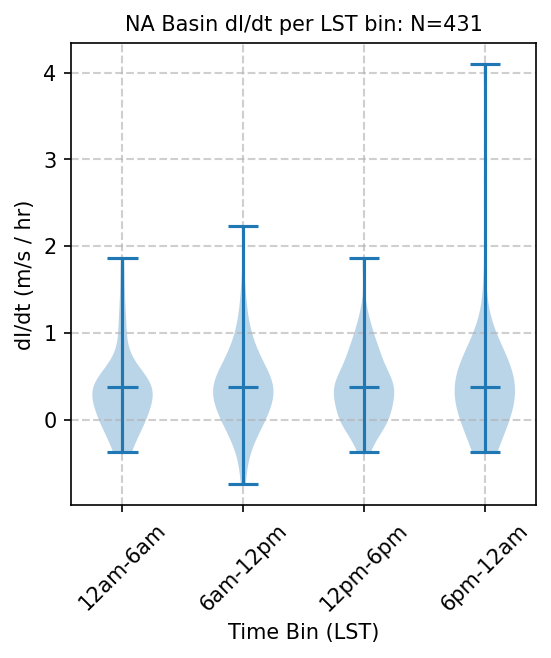

In [ ]:
#----------------- Generate Database -------------------------

sindices = np.arange(2221,4787)
basin = b'NA'
sigma = 0
nature = b'TS'
duration_thresh = 0

dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature, duration_thresh)

#------------------------ Figure -----------------------------

num_blocks = 4

bin1 = []
bin2 = []
bin3 = []
bin4 = []

for j in range(len(dIdt)):
    block = sort_genesis(num_blocks, ltimes[j])
    if block == 0:
        bin1.append(dIdt[j])
    elif block == 1:
        bin2.append(dIdt[j])
    elif block == 2:
        bin3.append(dIdt[j])
    else:
        bin4.append(dIdt[j])

fig, ax = plt.subplots(figsize=(4,4), dpi=150)

pos = np.arange(num_blocks)
data =[bin1, bin2, bin3, bin4]
cat = get_categories(num_blocks)

ax.violinplot(data, pos, showmeans=False, showmedians=True)
ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')
#ax.set_title(f"All Basins dI/dt per LST bin: N={count}", fontsize=10)
ax.set_title(f"{basin.decode('utf-8')} Basin dI/dt per LST bin: N={count}", fontsize=10)

if sigma != 0:
    fig.suptitle(f"'TS' {sigma} sigma clipping", color='gray')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

#### Violin plots decomposed into intensities

In [161]:
num_blocks = 4
sindices = np.arange(2221,4787)
basin = b'NI'
sigma = 0
nature = b'TS'
duration_thresh = 48

series = dict()
cat = get_categories(num_blocks)
pos = np.arange(num_blocks)

# generate dI/dt values
dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature, duration_thresh)

# create df of dIdt data
dIdts = []
times = []
LSTs = []
Iclass = []
Is = []

for index, time in enumerate(ltimes):
    I = Ivals[index]
    if I >= 17:
        block = sort_genesis(num_blocks, time)
        
        dIdts.append(dIdt[index])
        times.append(time)
        LSTs.append(block)
        Is.append(I)
        if I < 33:
            Iclass.append('17-33')
        elif I >= 33:
            Iclass.append('>33')

dIdt_df = pd.DataFrame({'dIdt': dIdts, 'I values': Is, 'ltimes': times, 'LST': LSTs, 'intensities': Iclass})

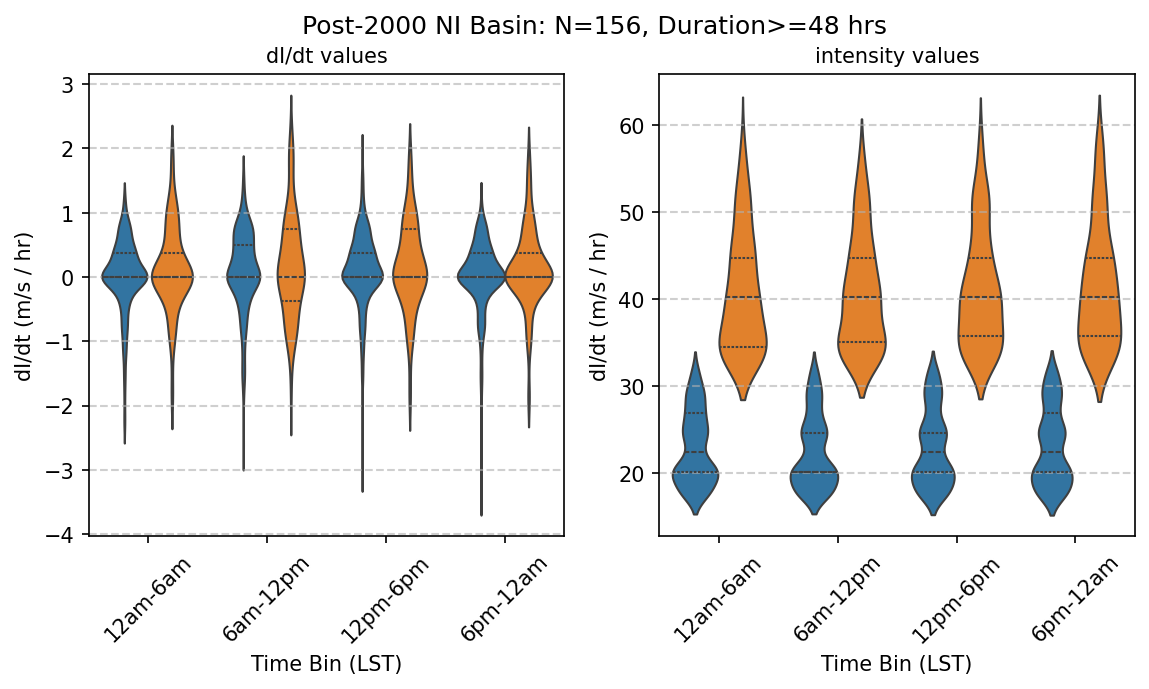

In [162]:
#------------------------ Violin Plot -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(9,4), dpi=150)

for i in range(2):
    axs[i].set_ylabel('dI/dt (m/s / hr)')
    axs[i].set_xlabel('Time Bin (LST)')
    axs[i].grid(alpha=0.6, linestyle='--', linewidth=1, which='both')
    
    axs[i].set_xticks(pos.T)
    axs[i].set_xticklabels(cat)
    plt.setp(axs[i].get_xticklabels(), rotation=45)

    if i == 0:
        sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='dIdt', hue='intensities',
                       ax=axs[i], linewidth=1, legend=False)
        axs[i].set_title(f"dI/dt values", fontsize=10)
    else:
        sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='I values', hue='intensities',
                       ax=axs[i], linewidth=1, legend=False)
        axs[i].set_title(f"intensity values", fontsize=10)
        #sns.move_legend(axs[i], "upper left", bbox_to_anchor=(1, 1))

if basin == "all":
    fig.suptitle(f"Post-2000 All Basins: N={count}, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

#### Violin Plots Max Accel

In [114]:
num_blocks = 4
sindices = np.arange(2221,4787)
basin = b'SP'
nature = b'TS'
duration_thresh = 48
threshold = "none"
accel_type = "max"

series = dict()
cat = get_categories(num_blocks)
pos = np.arange(num_blocks)

# generate max dI/dt values
maxdIdt, maxtimes, maxIvals, count = generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type)

# create df of dIdt data
dIdts = []
times = []
LSTs = []
Iclass = []
Is = []

# counts
midcount = 0
hicount = 0

for index, time in enumerate(maxtimes):
    I = maxIvals[index]
    if I >= 17:
        block = sort_genesis(num_blocks, time)
        
        dIdts.append(maxdIdt[index])
        times.append(time)
        LSTs.append(block)
        Is.append(I)
        if I < 33:
            midcount += 1
            Iclass.append('17-33')
        elif I >= 33:
            hicount += 1
            Iclass.append('>33')

dIdt_df = pd.DataFrame({'dIdt': dIdts, 'I values': Is, 'ltimes': times, 'LST': LSTs, 'intensities': Iclass})

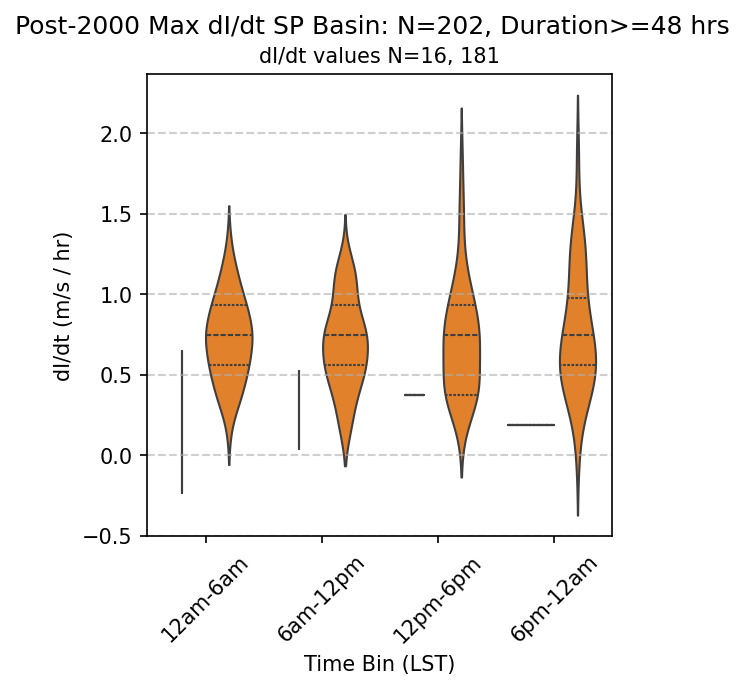

In [115]:
#------------------------ Max dI/dt Grouped Violin Plot -----------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=150)


ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='dIdt', hue='intensities',
               ax=ax, linewidth=1, hue_order=["17-33", ">33"], legend=False)
ax.set_title(f"dI/dt values N={midcount}, {hicount}", fontsize=10)

if basin == "all":
    fig.suptitle(f"Post-2000 Max dI/dt All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Max dI/dt {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

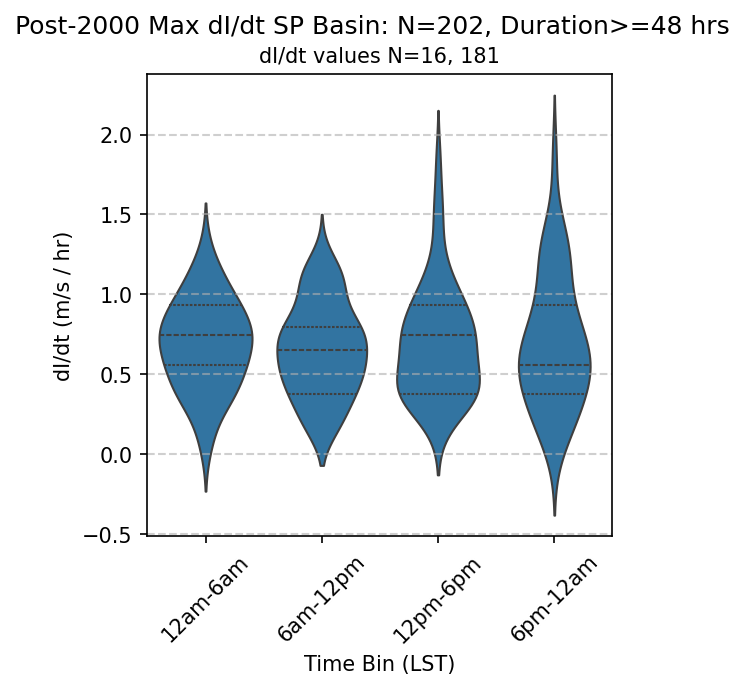

In [116]:
#------------------------ Max dI/dt Violin Plot -----------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=150)


ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='dIdt',
               ax=ax, linewidth=1, legend=False)
ax.set_title(f"dI/dt values N={midcount}, {hicount}", fontsize=10)

if basin == "all":
    fig.suptitle(f"Post-2000 Max dI/dt All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Max dI/dt {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

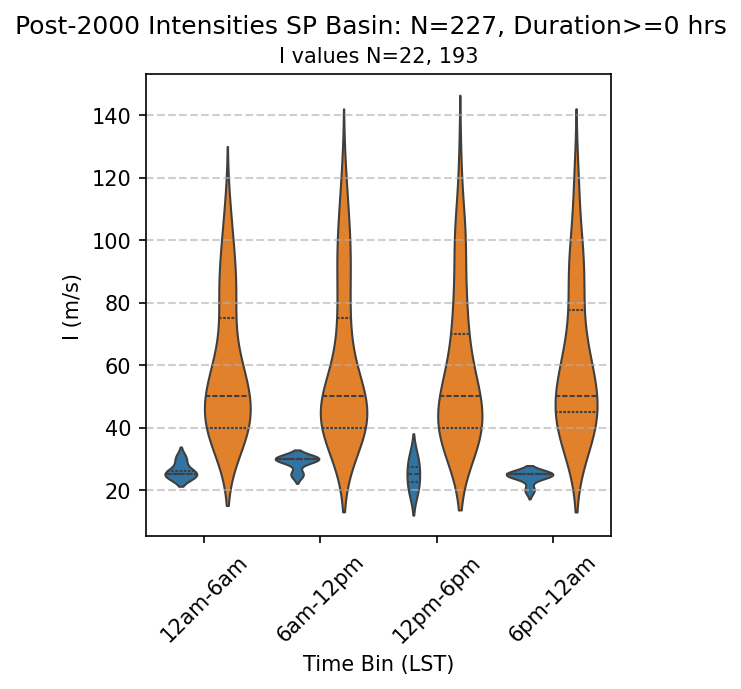

In [110]:
#------------------------ Intensity Violin Plot -----------------------------
fig, ax2 = plt.subplots(figsize=(4,4), dpi=150)

ax2.set_ylabel('I (m/s)')
ax2.set_xlabel('Time Bin (LST)')
ax2.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax2.set_xticks(pos.T)
ax2.set_xticklabels(cat)
plt.setp(ax2.get_xticklabels(), rotation=45)

sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='I values', hue='intensities',
               ax=ax2, linewidth=1, hue_order=["17-33", ">33"], legend=False)
ax2.set_title(f"I values N={midcount}, {hicount}", fontsize=10)
#sns.move_legend(ax2, "upper left", bbox_to_anchor=(1, 1))

if basin == "all":
    fig.suptitle(f"Post-2000 Intensities All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Intensities {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

### 2D histograms

In [158]:
 # generate dI/dt
sindices = np.arange(0,4787)
sigma = 0
basin = 'all'
nature = b'TS'

dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)
#dIdt, ltimes, Ivals, count = generate_dpdt(sindices, basin, sigma, nature)

1000 / 4787 databases loaded
2000 / 4787 databases loaded
3000 / 4787 databases loaded
4000 / 4787 databases loaded


#### Unnormalized

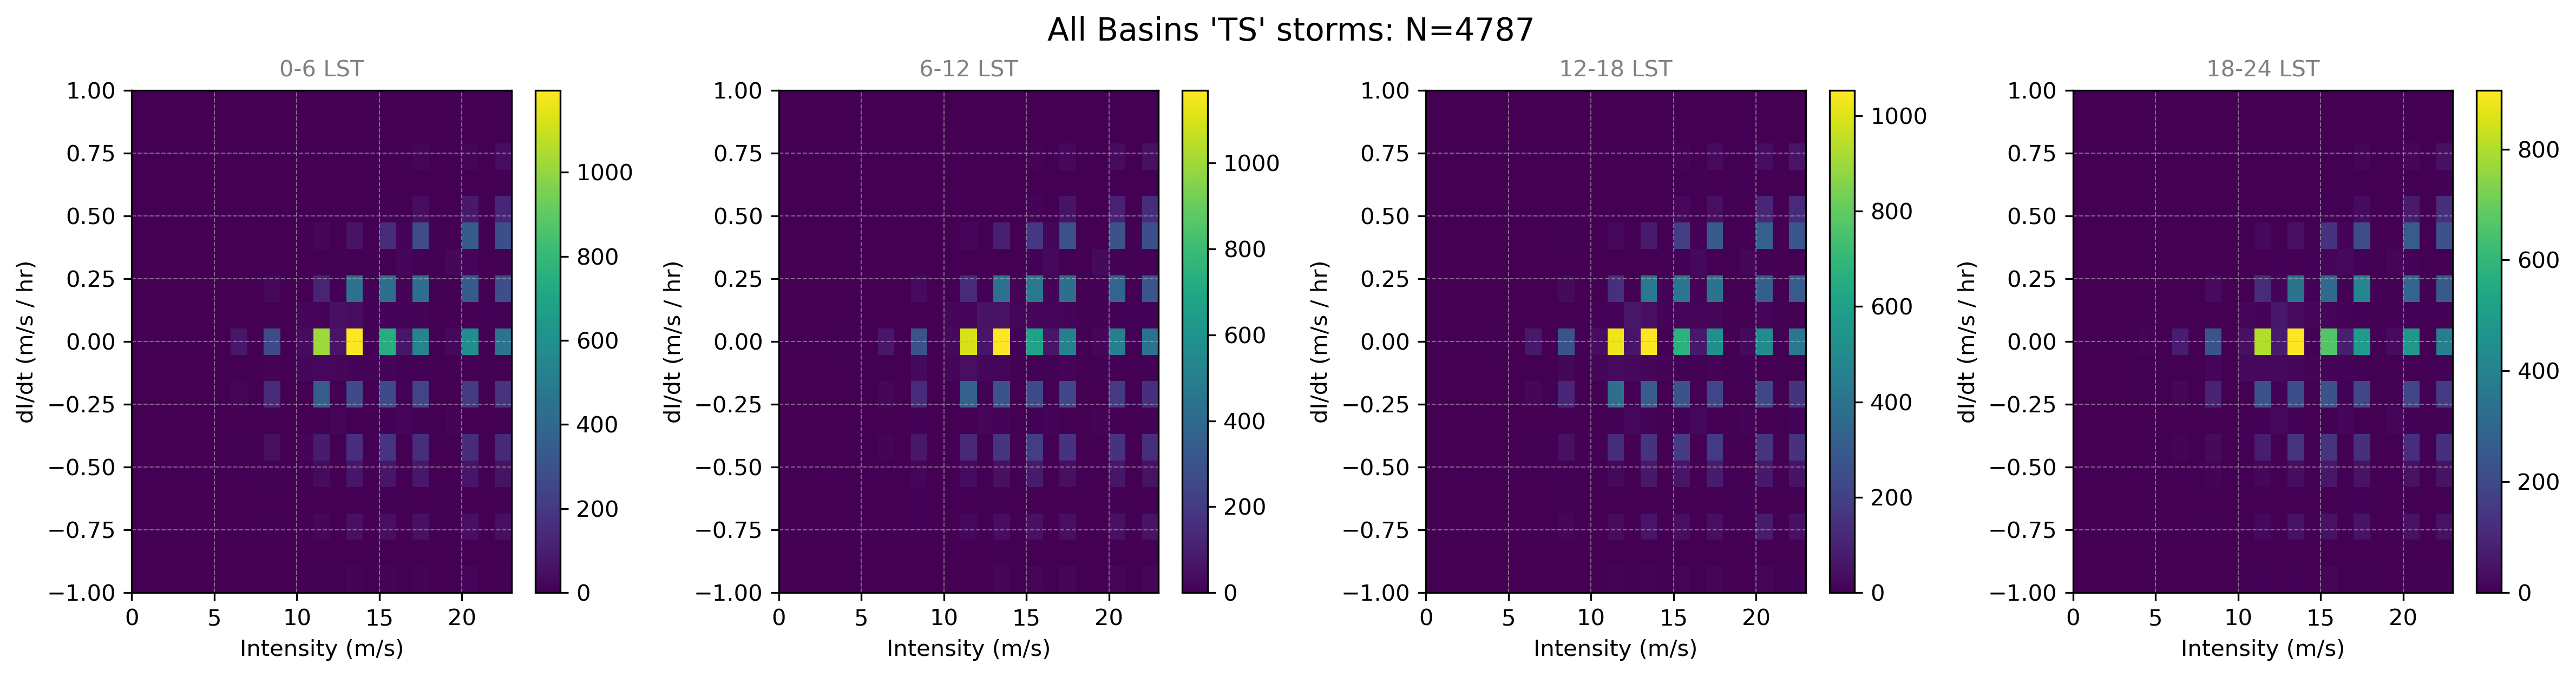

In [45]:
from matplotlib.ticker import MultipleLocator

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16,4), dpi=300)

for i in range(4):
    # sort time
    start_hr = 6*i
    stop_hr = start_hr+6
    
    mask = (ltimes > start_hr) & (ltimes <= stop_hr)
    x = Ivals[mask]
    y = dIdt[mask]

    # plot
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins=20)
    counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(0, 24, 1), np.linspace(-1, 1, 20)])

    '''
    # Zoom in: from chatgpt
    # 1. Find where the histogram peaks
    max_bin_index = np.unravel_index(np.argmax(counts), counts.shape)
    peak_x_bin = xedges[max_bin_index[0]]
    peak_y_bin = yedges[max_bin_index[1]]
    
    # 2. Define zoom window (e.g., +/- 1 bin width around peak)
    x_bin_width = xedges[1] - xedges[0]
    y_bin_width = yedges[1] - yedges[0]
    
    xlim = (max(min(x), peak_x_bin - 6 * x_bin_width), min(max(x), peak_x_bin + 7 * x_bin_width))
    ylim = (max(min(y), peak_y_bin - 3 * y_bin_width), min(max(y), peak_y_bin + 4 * y_bin_width))
    
    # 3. Apply zoom to axes
    axs[i].set_xlim(xlim)
    axs[i].set_ylim(ylim)
    '''

    # Title & grid
    axs[i].set_title(str(start_hr) + "-" + str(stop_hr) + " LST", fontsize=10, color='gray')
    fig.colorbar(im, ax=axs[i])
    
    axs[i].xaxis.set_minor_locator(MultipleLocator(5)) # Minor ticks every 0.2 units
    axs[i].yaxis.set_minor_locator(MultipleLocator(0.5))
    axs[i].grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    axs[i].grid(which='minor', alpha=0.3, linestyle='--', linewidth=0.5)
    axs[i].set_ylabel('dI/dt (m/s / hr)')
    #axs[i].set_ylabel('dp/dt (mb/hr)')
    axs[i].set_xlabel('Intensity (m/s)')
    #axs[i].set_xlabel('Intensity (mb)')
    

plt.tight_layout()

fig.suptitle ("All Basins '" + nature.decode("utf-8") + "' storms: N=" + str(count), y=1.03, fontsize=14)
#fig.suptitle(basin.decode("utf-8") + " Basin 'TS' storms: N=" + str(count))

plt.show()

#### Normalized histograms

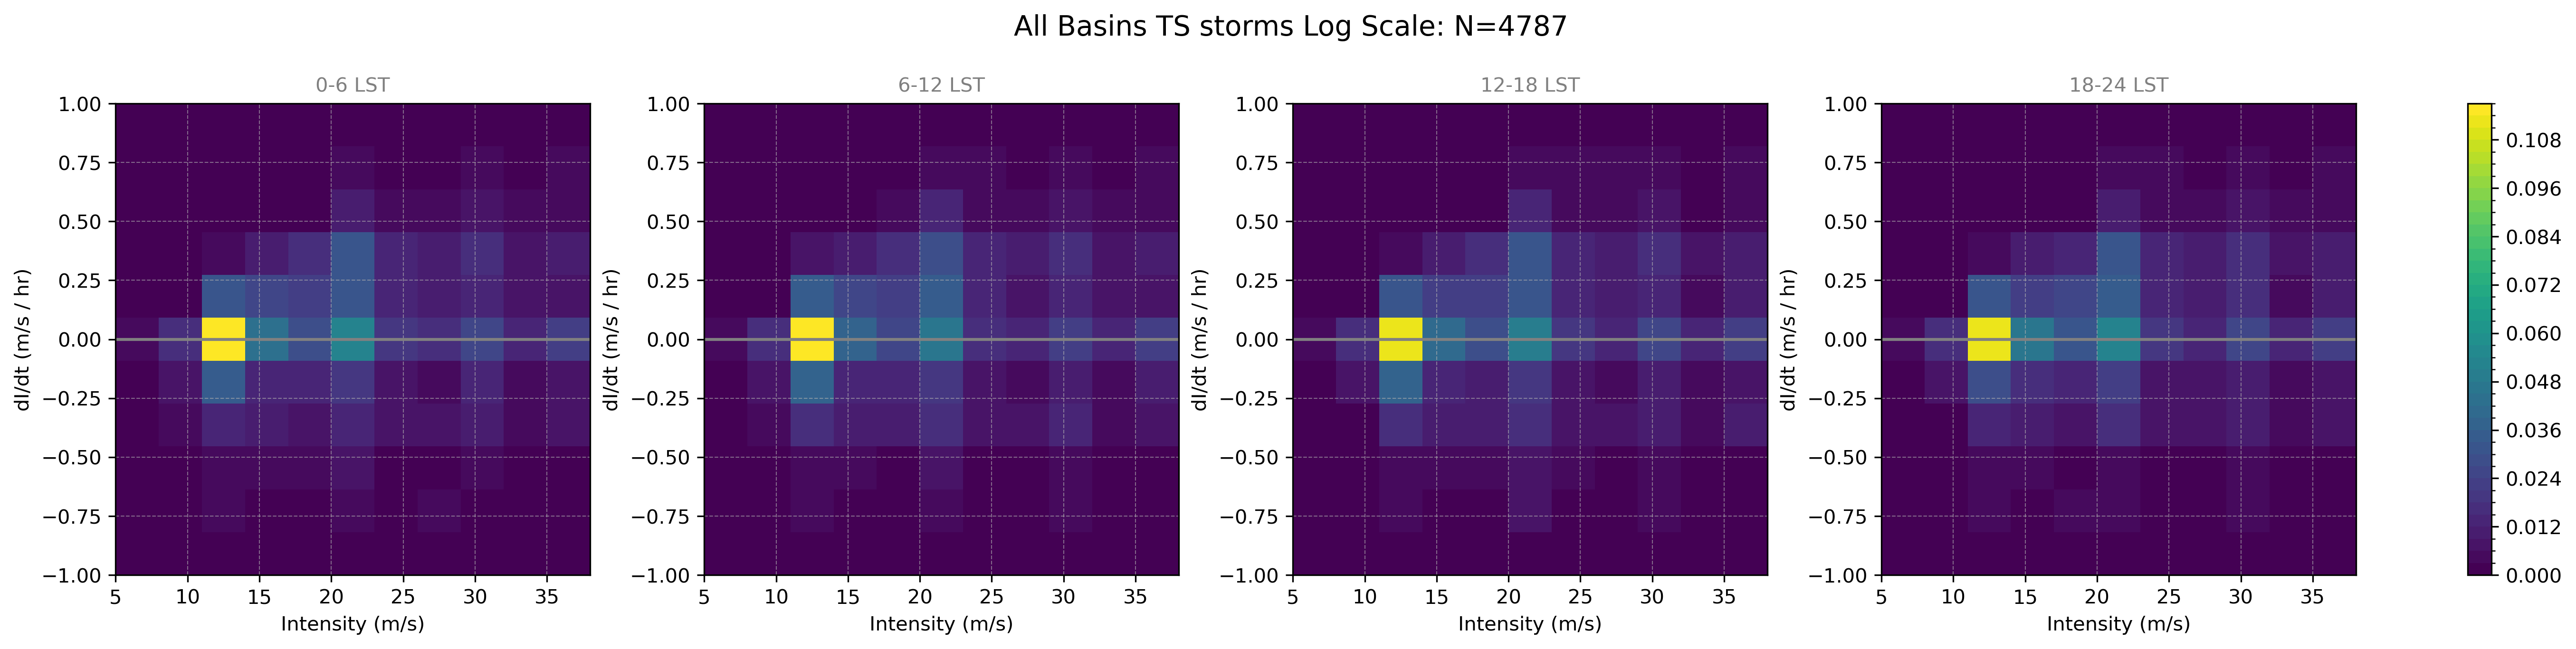

In [130]:
# Adapted from ChatGPT

from matplotlib.ticker import MultipleLocator
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

isZoom = 0 # 0 or 1
isNormalized = 'binned' # 'reg' = regular normalization, 'log' = log normalization, 'binned' = boundary normalization
removeMax = 0

# -------------------------- Figure --------------------------
if basin != 'all':
    basin_title = basin.decode('utf-8')
else:
    basin_title = 'All Basins'

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(18,4), dpi=300, constrained_layout=True)

max_count = 0
hist_data = []

for i in range(4):
    # sort time
    start_hr = 6*i
    stop_hr = start_hr+6
    
    mask = (ltimes > start_hr) & (ltimes <= stop_hr)
    
    x = Ivals[mask]
    y = dIdt[mask]

    # plot
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins=20)
    counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(5, 40, 3), np.linspace(-1, 1, 12)])
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(940, 1020, 5), np.linspace(-2, 2, 20)])
    #print(counts)

    if removeMax == 1:
        idx = np.argmax(counts)
        row, col = np.unravel_index(idx, counts.shape)
        counts[row, col] = 0
        #print(counts)

    # normalize for pdf
    counts = counts/np.sum(counts)
    #counts = counts/np.mean(counts)
    
    hist_data.append((counts, xedges, yedges, im))
    max_count = max(max_count, np.max(np.array(counts)))

max_count = round(max_count, 2)

# Normalize and set colormap
if isNormalized == 'reg':
    norm = Normalize(vmin=0, vmax=max_count)
    title = f"{basin_title} {nature.decode('utf-8')} storms: N={count}"
elif isNormalized == 'log':
    norm = matplotlib.colors.LogNorm(vmin=1, vmax=max_count)
    title = f"{basin_title} {nature.decode('utf-8')} storms Log Scale: N={count}"
elif isNormalized == 'binned':
    #norm = matplotlib.colors.BoundaryNorm(np.arange(0, 200, 40), 256)
    norm = matplotlib.colors.BoundaryNorm(np.arange(0, max_count, max_count/40), 256)
    title = f"{basin_title} {nature.decode('utf-8')} storms Log Scale: N={count}"

cmap = plt.cm.viridis


# Second loop: plot using pcolormesh (or imshow if preferred)
for i in range(4):
    counts, xedges, yedges, im = hist_data[i]
    pcm = axs[i].pcolormesh(xedges, yedges, counts.T, norm=norm, cmap=cmap)

    if isZoom == 1:
        # Zoom in: from chatgpt
        # 1. Find where the histogram peaks
        max_bin_index = np.unravel_index(np.argmax(counts), counts.shape)
        peak_x_bin = xedges[max_bin_index[0]]
        peak_y_bin = yedges[max_bin_index[1]]
        
        # 2. Define zoom window (e.g., +/- 1 bin width around peak)
        x_bin_width = xedges[1] - xedges[0]
        y_bin_width = yedges[1] - yedges[0]
        
        xlim = (max(min(x), peak_x_bin - 6 * x_bin_width), min(max(x), peak_x_bin + 7 * x_bin_width))
        ylim = (max(min(y), peak_y_bin - 3 * y_bin_width), min(max(y), peak_y_bin + 4 * y_bin_width))
        
        # 3. Apply zoom to axes
        axs[i].set_xlim(xlim)
        axs[i].set_ylim(ylim)
    
    # Title & grid
    axs[i].set_title(f"{6*i}-{6*(i+1)} LST", fontsize=10, color='gray')
    axs[i].xaxis.set_minor_locator(MultipleLocator(5)) # Minor ticks every 0.2 units
    axs[i].yaxis.set_minor_locator(MultipleLocator(0.5))
    axs[i].grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    axs[i].grid(which='minor', alpha=0.3, linestyle='--', linewidth=0.5)
    axs[i].set_ylabel('dI/dt (m/s / hr)')
    #axs[i].set_ylabel('dp/dt (mb/hr)')
    axs[i].set_xlabel('Intensity (m/s)')
    axs[i].axhline(0, color='gray')
    #axs[i].set_xlabel('Intensity (mb)')

# Shared colorbar
fig.colorbar(pcm, ax=axs, location='right')

fig.suptitle(f"{title}", y=1.1, fontsize=14)
#plt.tight_layout()
plt.show()

#### Anomaly 2D histograms

1000 / 4787 databases loaded
2000 / 4787 databases loaded
3000 / 4787 databases loaded
4000 / 4787 databases loaded


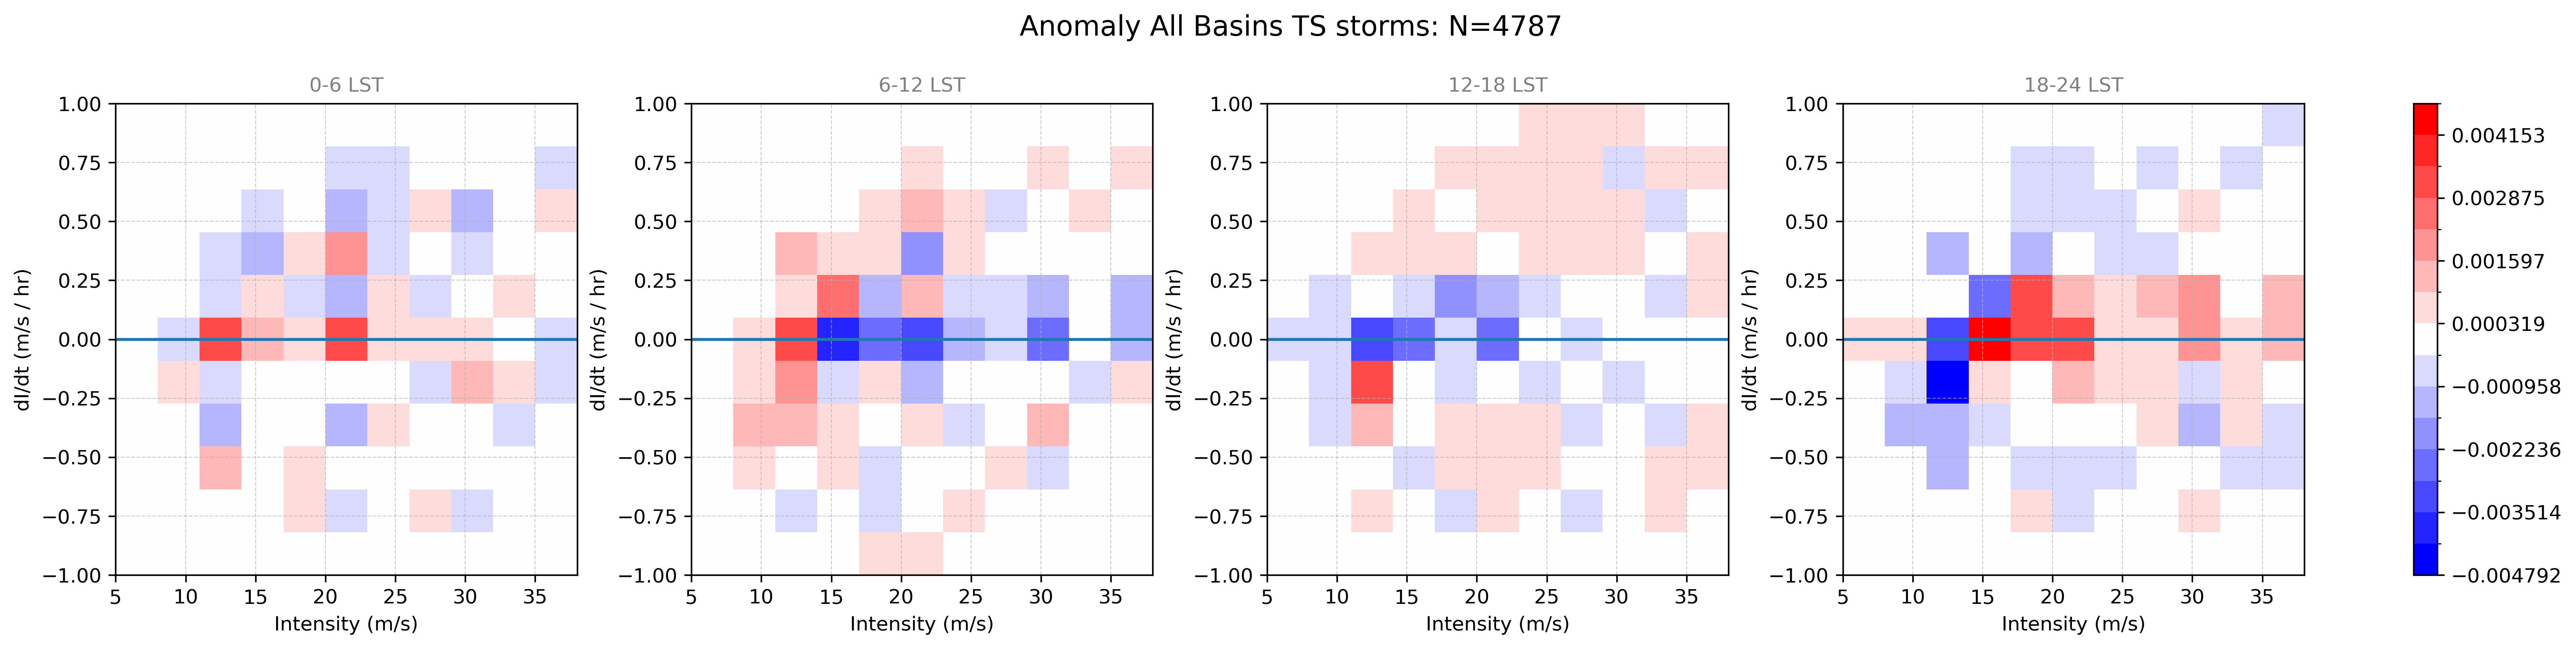

In [159]:
# Plot anomalies
dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)

# Adapted from ChatGPT

from matplotlib.ticker import MultipleLocator
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

isZoom = 0 # 0 or 1
isNormalized = 'extrema' # 'reg' = regular normalization, 'log' = log normalization, 'binned' = boundary normalization
removeMax = 0
isAnomaly = 1

# -------------------------- Figure --------------------------
if basin != 'all':
    basin_title = basin.decode('utf-8')
else:
    basin_title = 'All Basins'

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(18,4), dpi=300, constrained_layout=True)

max_count = 0
min_count = 0
temp_hist = []
hist_data = []
hist_sum = np.zeros((11,11))

for i in range(4):
    # sort time
    start_hr = 6*i
    stop_hr = start_hr+6
    
    mask = (ltimes > start_hr) & (ltimes <= stop_hr)
    x = Ivals[mask]
    y = dIdt[mask]

    # plot
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins=20)
    counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(5, 40, 3), np.linspace(-1, 1, 12)])
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(940, 1020, 5), np.linspace(-2, 2, 20)])

    if removeMax == 1:
        idx = np.argmax(counts)
        row, col = np.unravel_index(idx, counts.shape)
        counts[row, col] = 0

    counts = counts/(np.sum(counts))
    
    hist_sum = hist_sum + counts

    temp_hist.append((counts, xedges, yedges, im))
    
hist_avg = hist_sum/4

# store anomaly data in hist_data
for i in range(4):
    counts = temp_hist[i][0] - hist_avg
    #counts = counts/(np.sum(counts)) # normalize
    hist_data.append((counts, xedges, yedges, im))
    max_count = max(max_count, np.max(np.array(counts)))
    min_count = min(min_count, np.min(np.array(counts)))


# Normalize and set colormap
if isNormalized == 'reg':
    #norm = Normalize(vmin=min_count, vmax=max_count)
    norm = matplotlib.colors.CenteredNorm()
    title = f"{basin_title} {nature.decode('utf-8')} storms: N={count}"
    cmap = plt.cm.viridis
elif isNormalized == 'log':
    norm = matplotlib.colors.LogNorm(vmin=1e-6, vmax=max_count)
    title = f"{basin_title} {nature.decode('utf-8')} storms Log Scale: N={count}"
    cmap = plt.cm.viridis
elif isNormalized == 'binned':
    norm = matplotlib.colors.BoundaryNorm(np.arange(0, 200, 40), 256)
    title = f"{basin_title} {nature.decode('utf-8')} storms: N={count}"
    cmap = plt.cm.viridis
elif isNormalized == 'extrema':
    extremum = max([abs(min_count), abs(max_count)])
    norm = matplotlib.colors.BoundaryNorm(np.linspace(-extremum, extremum, 16), 256)
    title = f"{basin_title} {nature.decode('utf-8')} storms: N={count}"
    cmap = matplotlib.cm.bwr

if isAnomaly == 1:
    title = f"Anomaly {title}"


# Second loop: plot using pcolormesh (or imshow if preferred)
for i in range(4):
    counts, xedges, yedges, im = hist_data[i]
    pcm = axs[i].pcolormesh(xedges, yedges, counts.T, norm=norm, cmap=cmap)

    # Zoom in: from chatgpt
    if isZoom == 1:
        # 1. Find where the histogram peaks
        max_bin_index = np.unravel_index(np.argmax(counts), counts.shape)
        peak_x_bin = xedges[max_bin_index[0]]
        peak_y_bin = yedges[max_bin_index[1]]
        
        # 2. Define zoom window (e.g., +/- 1 bin width around peak)
        x_bin_width = xedges[1] - xedges[0]
        y_bin_width = yedges[1] - yedges[0]
        
        xlim = (max(min(x), peak_x_bin - 6 * x_bin_width), min(max(x), peak_x_bin + 7 * x_bin_width))
        ylim = (max(min(y), peak_y_bin - 3 * y_bin_width), min(max(y), peak_y_bin + 4 * y_bin_width))
        
        # 3. Apply zoom to axes
        axs[i].set_xlim(xlim)
        axs[i].set_ylim(ylim)
    
    # Title & grid
    axs[i].set_title(f"{6*i}-{6*(i+1)} LST", fontsize=10, color='gray')
    axs[i].xaxis.set_minor_locator(MultipleLocator(5)) # Minor ticks every 0.2 units
    axs[i].yaxis.set_minor_locator(MultipleLocator(0.5))
    axs[i].grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    axs[i].grid(which='minor', alpha=0.3, linestyle='--', linewidth=0.5)
    axs[i].set_ylabel('dI/dt (m/s / hr)')
    #axs[i].set_ylabel('dp/dt (mb/hr)')
    axs[i].set_xlabel('Intensity (m/s)')
    axs[i].axhline(0,)
    #axs[i].set_xlabel('Intensity (mb)')

# Shared colorbar
fig.colorbar(pcm, ax=axs, location='right')
fig.suptitle(f"{title}", y=1.1, fontsize=14)
plt.show()

#### Average 2D histogram

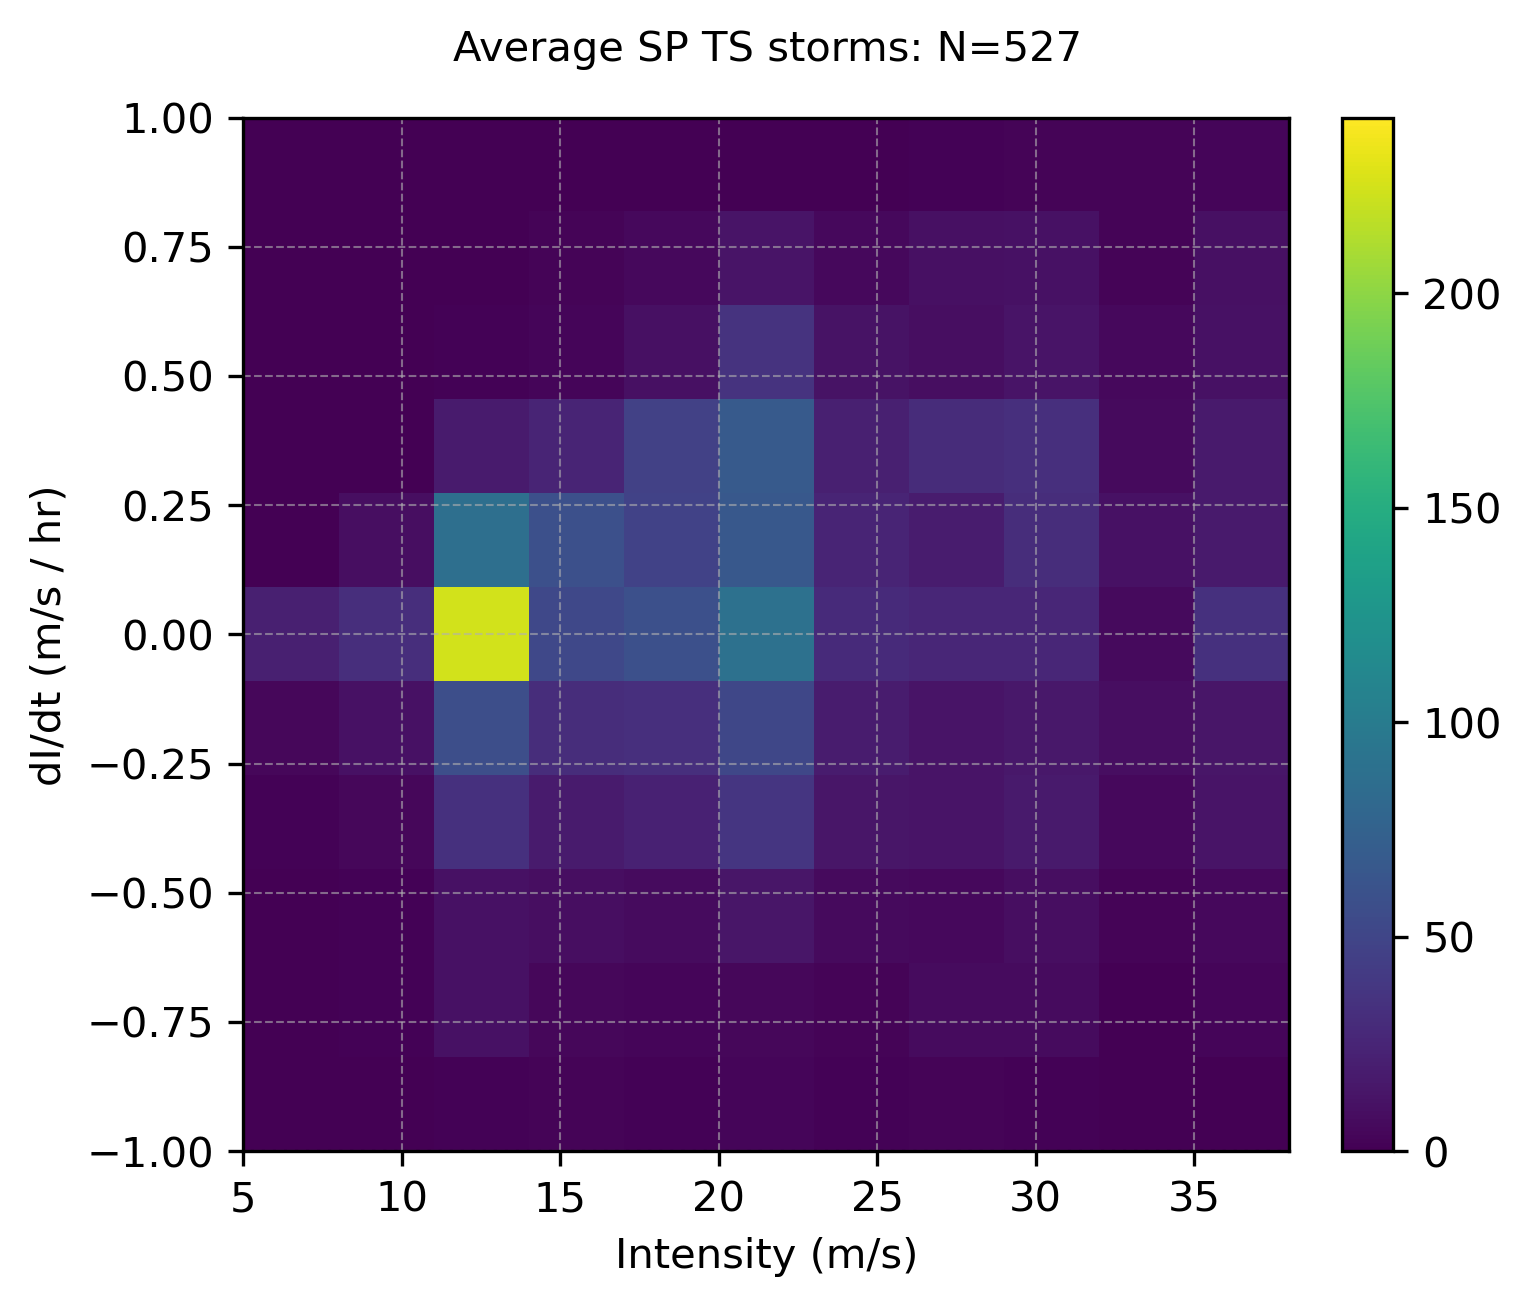

In [129]:
# Plot Average 
basin = b'SP'
dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)

# Adapted from ChatGPT

from matplotlib.ticker import MultipleLocator
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

isZoom = 0 # 0 or 1
isNormalized = 'reg' # 'reg' = regular normalization, 'log' = log normalization, 'binned' = boundary normalization
removeMax = 0
isAnomaly = 1
# -------------------------- Figure --------------------------
if basin != 'all':
    basin_title = basin.decode('utf-8')
else:
    basin_title = 'All Basins'

fig, ax = plt.subplots(figsize=(5,4), dpi=300, constrained_layout=True)

max_count = 0
temp_hist = []
hist_data = []
hist_sum = np.zeros((11,11))

for i in range(4):
    # sort time
    start_hr = 6*i
    stop_hr = start_hr+6
    
    mask = (ltimes > start_hr) & (ltimes <= stop_hr)
    x = Ivals[mask]
    y = dIdt[mask]

    # plot
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins=20)
    counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(5, 40, 3), np.linspace(-1, 1, 12)])
    #counts, xedges, yedges, im = axs[i].hist2d(x, y, bins = [np.arange(940, 1020, 5), np.linspace(-2, 2, 20)])
    #print(counts)

    if removeMax == 1:
        idx = np.argmax(counts)
        row, col = np.unravel_index(idx, counts.shape)
        counts[row, col] = 0
        #print(counts)

    hist_sum = hist_sum + counts
    #print(f"hist_sum: {hist_sum}")

    temp_hist.append((counts, xedges, yedges, im))
    max_count = max(max_count, np.max(np.array(counts)))
    
hist_avg = hist_sum/4

# store anomaly data in hist_data
for i in range(4):
    counts = temp_hist[i][0] - hist_avg
    #print(f"counts: {counts}")
    hist_data.append((counts, xedges, yedges, im))
    #max_count = max(max_count, np.max(np.array(counts)))

# Normalize and set colormap
if isNormalized == 'reg':
    norm = Normalize(vmin=0, vmax=max_count)
    title = f"{basin_title} {nature.decode('utf-8')} storms: N={count}"
elif isNormalized == 'log':
    norm = matplotlib.colors.LogNorm(vmin=1, vmax=max_count)
    title = f"{basin_title} {nature.decode('utf-8')} storms Log Scale: N={count}"
elif isNormalized == 'binned':
    norm = matplotlib.colors.BoundaryNorm(np.arange(0, 200, 40), 256)
    title = f"{basin_title} {nature.decode('utf-8')} storms Log Scale: N={count}"

#if isAnomaly == 1:
title = f"Average {title}"

cmap = plt.cm.viridis


# Plot Average
x, xedges, yedges, im = hist_data[0]
counts = hist_avg
pcm = ax.pcolormesh(xedges, yedges, counts.T, norm=norm, cmap=cmap)

# Title & grid
#ax.set_title(f"{6*i}-{6*(i+1)} LST", fontsize=10, color='gray')
ax.xaxis.set_minor_locator(MultipleLocator(5)) # Minor ticks every 0.2 units
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
ax.grid(which='minor', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_ylabel('dI/dt (m/s / hr)')
#ax.set_ylabel('dp/dt (mb/hr)')
ax.set_xlabel('Intensity (m/s)')
#ax.set_xlabel('Intensity (mb)')

# Shared colorbar
fig.colorbar(pcm, ax=ax, location='right')

fig.suptitle(f"{title}", y=1.05, fontsize=10)
#plt.tight_layout()
plt.show()

## p value dI/dt

In [78]:
# ----------------- Generate Database -------------------------
num_blocks = 4
sindices = np.arange(0,4787)
basin = b'SI'
sigma = 0
nature = b'TS'

dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)

# ------------------------ P-value test ------------------------
pvalue = ks2samp_pvalue(dIdt, max(dIdt))
print(f"p value: {pvalue}")

[0.99989834 0.86121996 0.83885409 ... 3.12887884 1.13517959 1.43229945]
p value: 0.0


## multiple intensity categories

In [63]:
# ----------------- Generate Database -------------------------
num_blocks = 4
sindices = np.arange(2221,4787)
basin = b'SI'
sigma = 0
nature_types = [b'TS', b'DS', b'ET', b'SS', b'MX']

series = dict()

for nature in nature_types:
    dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)
    
    # ------------------------ Find Average dI/dt ------------------------
    bin1 = []
    bin2 = []
    bin3 = []
    bin4 = []
    
    for j in range(len(dIdt)):
        block = sort_genesis(num_blocks, ltimes[j])
        if block == 0:
            bin1.append(dIdt[j])
        elif block == 1:
            bin2.append(dIdt[j])
        elif block == 2:
            bin3.append(dIdt[j])
        else:
            bin4.append(dIdt[j])
    
    bin1 = np.array(bin1)
    bin2 = np.array(bin2)
    bin3 = np.array(bin3)
    bin4 = np.array(bin4)

    all_bins = [bin1, bin2, bin3, bin4]
    
    valid_means = []

    for eachbin in all_bins:
        mean = np.nanmean(eachbin)
        if np.isnan(mean):
            valid_means.append(0)
            continue
        valid_means.append(mean)
    
    series[nature] = np.array(valid_means)
    #errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])

series

{b'TS': array([0.01591095, 0.02933515, 0.01937021, 0.02098537]),
 b'DS': array([-0.02483596, -0.02263037, -0.02499516, -0.02011658]),
 b'ET': array([-0.08697446, -0.0985193 , -0.06070047, -0.08840212]),
 b'SS': array([0.01972267, 0.04035843, 0.02197027, 0.0273926 ]),
 b'MX': array([-0.00942403, -0.02005388, -0.01770817, -0.00796365])}

[None, None, None, None]

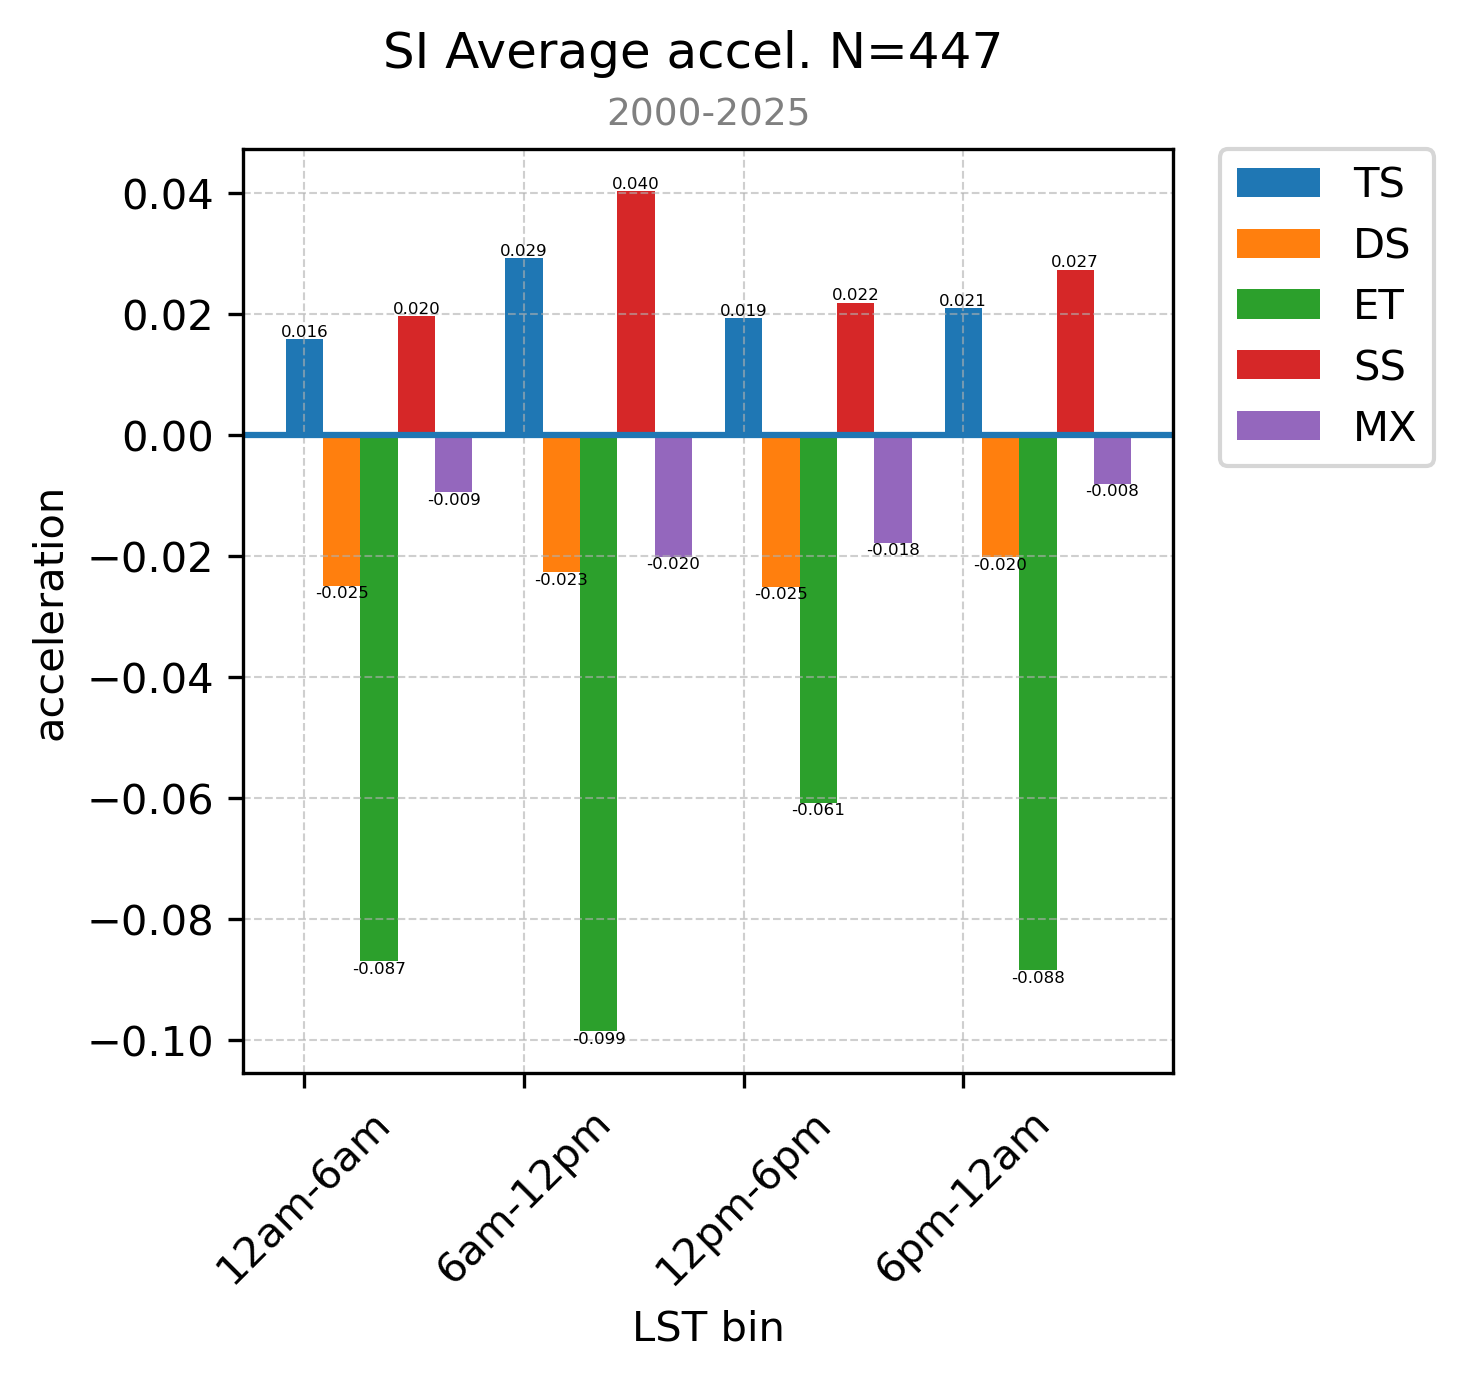

In [64]:
# ------------------------ Plot Figure ------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

cat = get_categories(num_blocks)

x = np.arange(len(cat))  # the label locations
width = 0.17
multiplier = 0

for nature in nature_types:
    offset = width * multiplier
    #ax.bar(x + offset, series[nature], width, capsize=3, label=nature.decode('utf-8'))
    rects = ax.bar(x + offset, series[nature], width, label=nature.decode('utf-8'))
    ax.bar_label(rects, label_type='edge', fmt='%.3f', fontsize=4)
    multiplier += 1
    #ax.bar(x - width/2, series[nature], width=0.4, capsize=3, color='lightcoral', label='dI/dt (m/s / hr)')

ax.axhline(0,)
ax.set_xticks(x)
ax.set_xticklabels(cat)
ax.set_xlabel('LST bin')
ax.set_ylabel('acceleration')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Places legend outside to the right

if basin == 'all':
    fig.suptitle(f"All Basins Average accel. N={count}")
else:
    fig.suptitle(f"{basin.decode('utf-8')} Average accel. N={count}")
#ax.set_title(f"{nature.decode('utf-8')} category only", fontsize=9, color='gray')
ax.set_title(f"2000-2025", fontsize=9, color='gray')

plt.setp(ax.get_xticklabels(), rotation=45)

## dI/dt vs. dp/dt

In [61]:
# ----------------- Generate Database -------------------------
num_blocks = 4
sindices = np.arange(0,4787)
basin = b'EP'
sigma = 0
nature = b'TS'

dIdt, ltimes, Ivals, count = generate_intensities(sindices, basin, sigma, nature)
dpdt, ptimes, pvals, p_count = generate_dpdt(sindices, basin, sigma, nature)

# ------------------------ Find Average dI/dt ------------------------
bin1 = []
bin2 = []
bin3 = []
bin4 = []

for j in range(len(dIdt)):
    block = sort_genesis(num_blocks, ltimes[j])
    if block == 0:
        bin1.append(dIdt[j])
    elif block == 1:
        bin2.append(dIdt[j])
    elif block == 2:
        bin3.append(dIdt[j])
    else:
        bin4.append(dIdt[j])

bin1 = np.array(bin1)
bin2 = np.array(bin2)
bin3 = np.array(bin3)
bin4 = np.array(bin4)

dIdt_hist = np.array([bin1.mean(), bin2.mean(), bin3.mean(), bin4.mean()])
errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])

cat = get_categories(num_blocks)

# ------------------------ Find Average dp/dt ------------------------
pbin1 = []
pbin2 = []
pbin3 = []
pbin4 = []

for j in range(len(dpdt)):
    block = sort_genesis(num_blocks, ptimes[j])
    if block == 0:
        pbin1.append(dpdt[j])
    elif block == 1:
        pbin2.append(dpdt[j])
    elif block == 2:
        pbin3.append(dpdt[j])
    else:
        pbin4.append(dpdt[j])

pbin1 = np.array(pbin1)
pbin2 = np.array(pbin2)
pbin3 = np.array(pbin3)
pbin4 = np.array(pbin4)

dpdt_hist = np.array([pbin1.mean(), pbin2.mean(), pbin3.mean(), pbin4.mean()])
perrors = np.array([pbin1.std(), pbin2.std(), pbin3.std(), pbin4.std()])

[None, None, None, None]

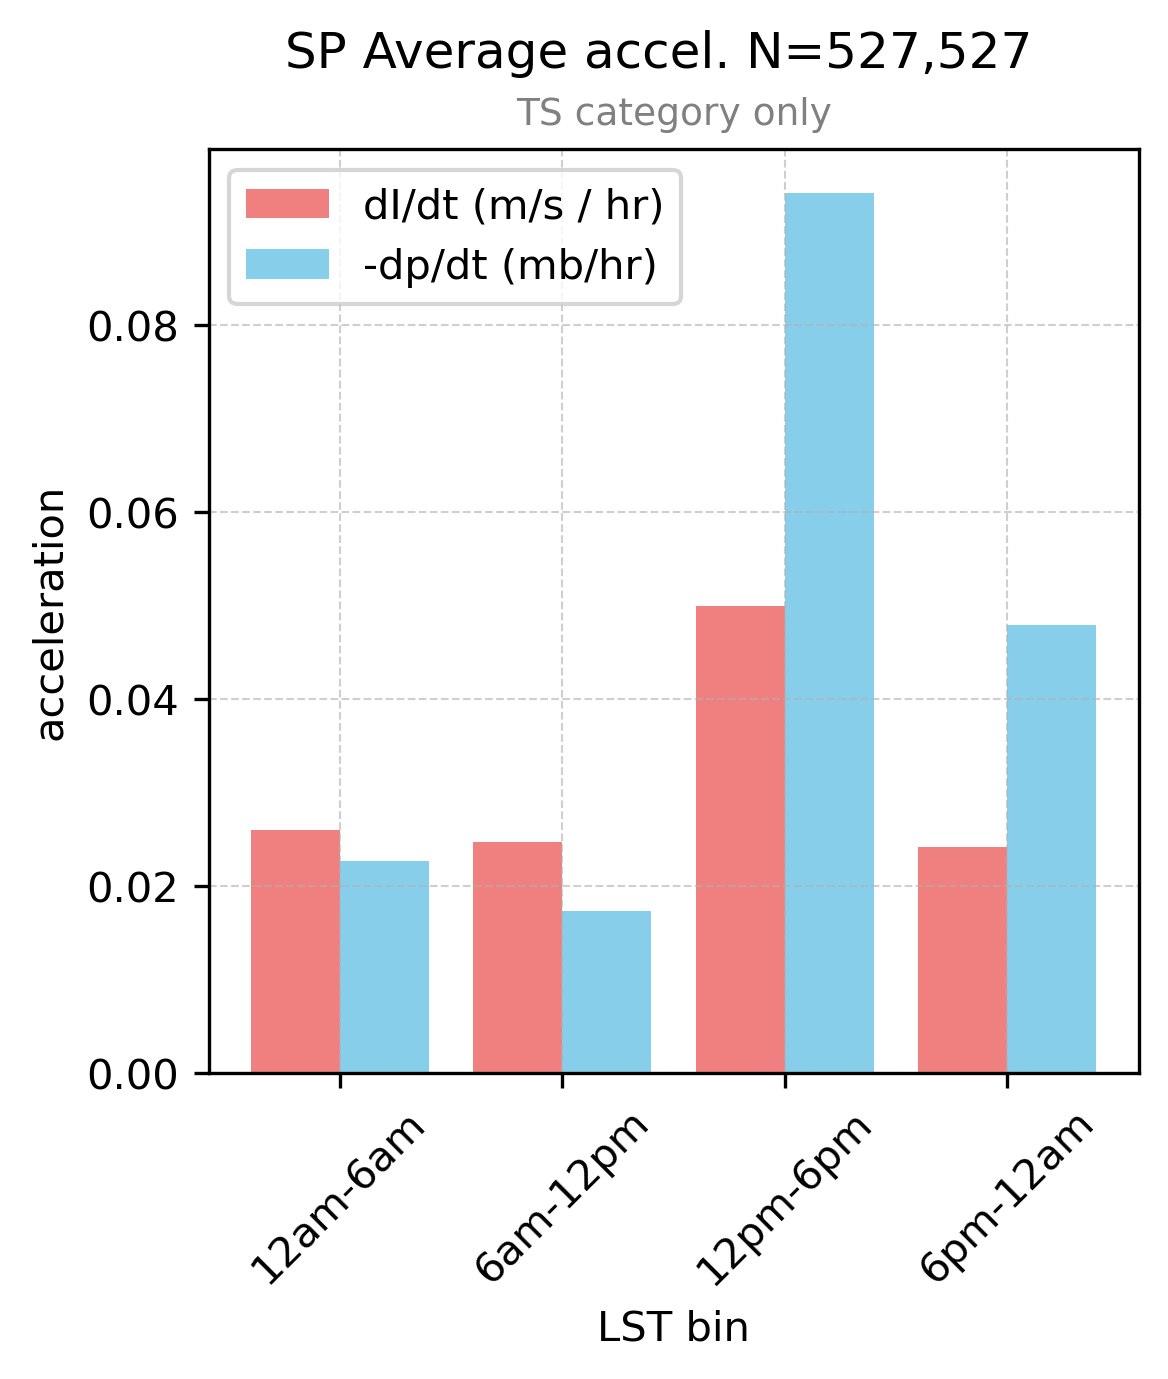

In [60]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

x = np.arange(len(cat))  # the label locations
width = 0.4

ax.bar(x - width/2, dIdt_hist, width=0.4, capsize=3, color='lightcoral', label='dI/dt (m/s / hr)')
ax.bar(x + width/2, dpdt_hist*(-1), width=0.4, capsize=3, color='skyblue', label='-dp/dt (mb/hr)')

ax.set_xticks(x)
ax.set_xticklabels(cat)
ax.set_xlabel('LST bin')
ax.set_ylabel('acceleration')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()

if basin == 'all':
    fig.suptitle(f"All Basins Average accel. N={count},{p_count}")
else:
    fig.suptitle(f"{basin.decode('utf-8')} Average accel. N={count},{p_count}")
ax.set_title(f"{nature.decode('utf-8')} category only", fontsize=9, color='gray')

plt.setp(ax.get_xticklabels(), rotation=45)

## intensification vs. weakening

### before vs. after max acceleration

In [161]:
'''
Returns dIdt (list of delta intensities between each 3 hour interval) and ltimes (list of hours associated with each delta).
Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
'''

def generate_split_intensities(sindices, basin, nature, duration_thresh):
    intensifying = []
    weakening = []

    Ival_i = []
    Ival_w = []

    ltimes_i = []
    ltimes_w = []
    
    count = 0
    
    # dates
    year_ds = IBTrACS_ds.where((IBTrACS_ds['storm'] >= min(sindices)) & (IBTrACS_ds['storm'] <= max(sindices)), drop=True)
    
    if basin != 'all':
        basin_ds = year_ds.where((year_ds['basin'] == basin), drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = year_ds

    
    # append genesis times to histogram
    for storm_index in sindices:
        
        dIdt = [] # dt = 3 hours
        Ivals = []
        ltimes = [] # local times associated with each dIdt point
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        
        # find intensities
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        
        # find times
        time_clean = storm_data['time'][mask].values
        if len(time_clean) == 0:
            continue
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]

        # filter out storms lasting under X hours
        storm_duration = (times[len(times)-1] - times[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
                
        assert len(intensities) == len(times)

        # find dI/dt
        for i in range(1,len(intensities)-1):
            if storm_data['nature'][mask].values[i] != nature: # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i-1]).total_seconds()/3600
            if delta < 0:
                print("ahead:", times[i+1])
                print("behind:", times[i-1])
                print("delta:",delta)
                print("times:")
                print(times)
            dIdt.append((intensities[i+1]-intensities[i-1])/delta)
            Ivals.append(intensities[i+1])
            ltimes.append(times[i+1].hour) # basically remove first data point from times

        if len(dIdt) == 0:
            continue
        
        count += 1

        # convert to m/s (IBTrACS wind speed is in kts)
        dIdt = np.array(dIdt)/2.2369
        ltimes = np.array(ltimes)
        Ivals = np.array(Ivals)/2.2369
        
        # separate into weak vs. weakening
        max_index = np.argmax(dIdt)
                
        [intensifying.append(value) for value in dIdt[:max_index]]
        [weakening.append(value) for value in dIdt[max_index+1:]]

        [Ival_i.append(value) for value in Ivals[:max_index]]
        [Ival_w.append(value) for value in Ivals[max_index+1:]]

        [ltimes_i.append(value) for value in ltimes[:max_index]]
        [ltimes_w.append(value) for value in ltimes[max_index+1:]]
        
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    return intensifying, weakening, ltimes_i, ltimes_w, Ival_i, Ival_w, count

1000 / 4787 databases loaded
2000 / 4787 databases loaded
3000 / 4787 databases loaded
[ 3  0 10 ... 14  0  9]
[10 15 15 ... 18 14 15]


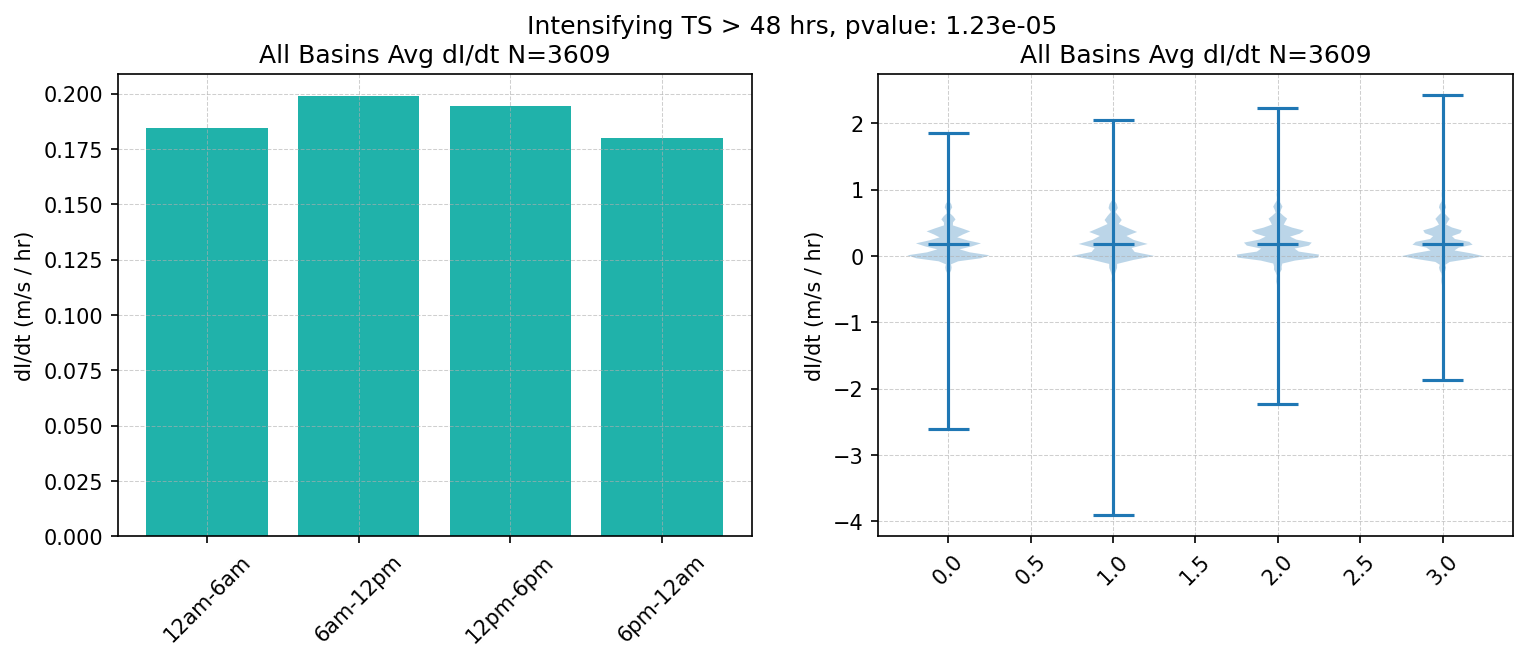

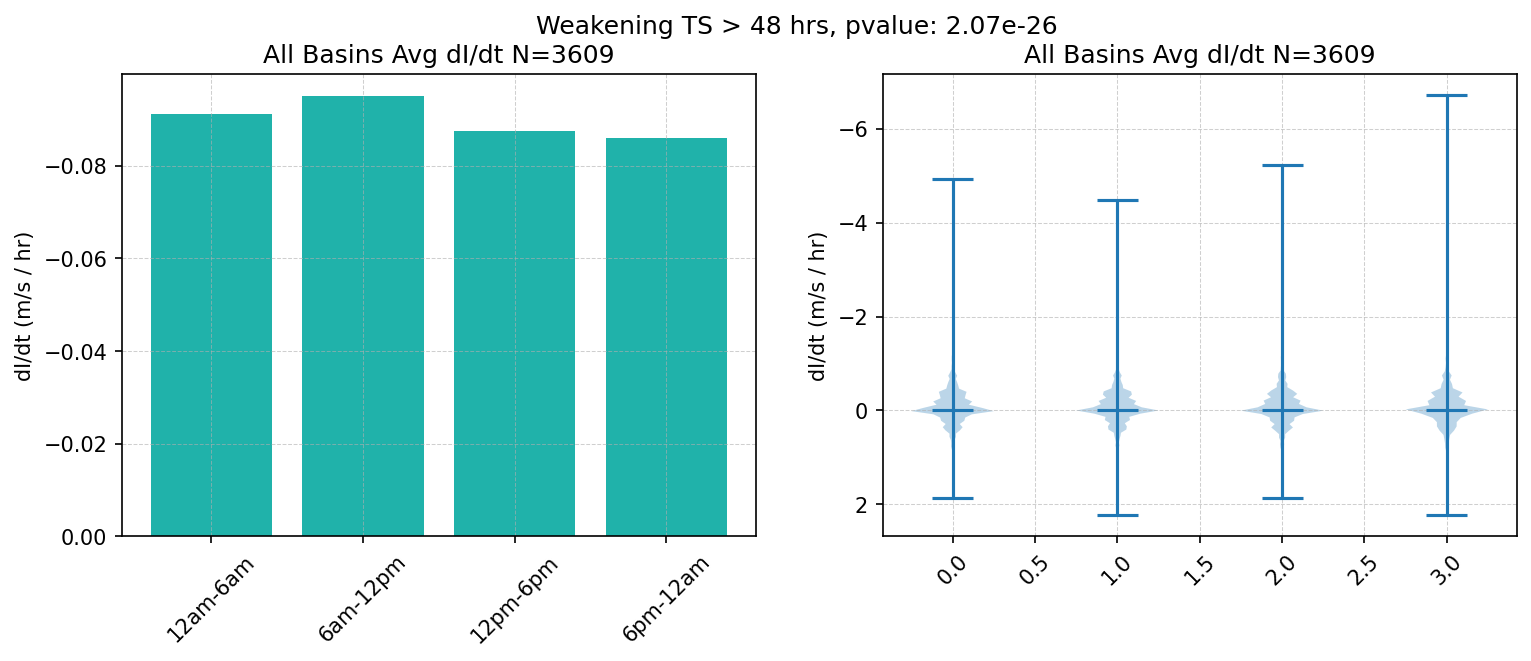

In [54]:
sindices = np.arange(0,4787)
basin = 'all'
nature = b'TS'
dur_thresh = 48

inten, weak, li, lw, Ival_i, Ival_w, count =  generate_split_intensities(sindices, basin, nature, dur_thresh)

# p-value
pval_li = f"{float(ks2samp_pvalue(li, 24)):.2e}"
pval_lw = f"{float(ks2samp_pvalue(lw, 24)):.2e}"

if basin == 'all':
    subtitle = f"All Basins Avg dI/dt N={count}"
else:
    subtitle = f"{basin.decode('utf-8')} Basin Avg dI/dt N={count}"

title = f"{nature.decode('utf-8')} > {dur_thresh} hrs"


new_title = f"Intensifying {title}, pvalue: {pval_li}"
dIdt_hist1x2(inten, li, new_title, subtitle, 0)

new2_title = f"Weakening {title}, pvalue: {pval_lw}"
dIdt_hist1x2(weak, lw, new2_title, subtitle, 1)

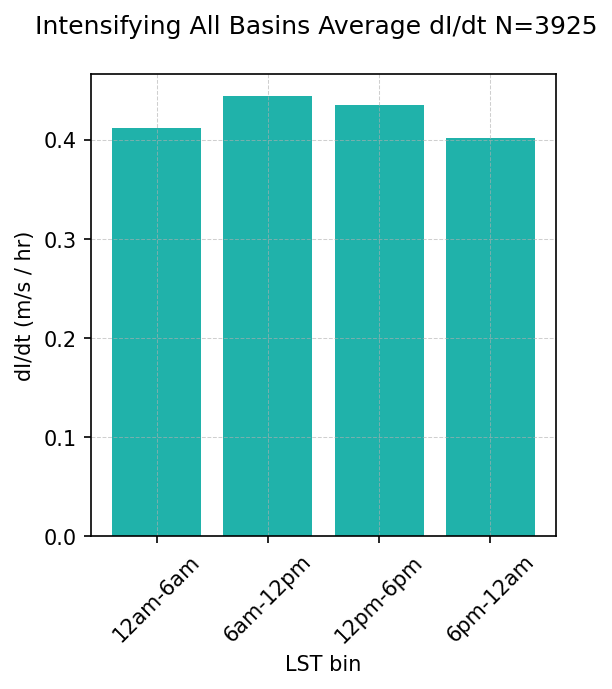

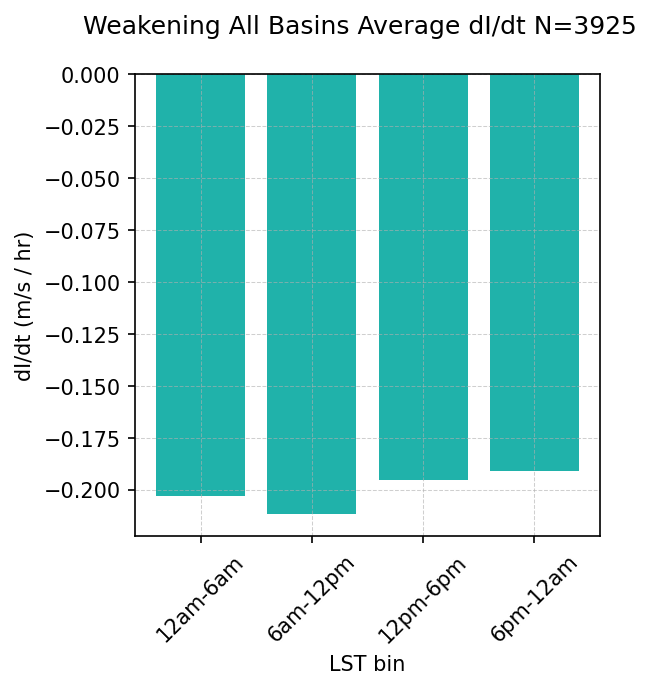

In [133]:
# ------------- Plots -----------
if basin == 'all':
    title = f"All Basins Average dI/dt N={count}"
    subtitle = ""
else:
    title = f"{basin.decode('utf-8')} Average dI/dt N={count}"
    subtitle = f"{nature.decode('utf-8')} category only - filtered > {duration} hrs"

new_title = f"Intensifying {title}"
avg_dIdt_hist(inten, li, new_title, subtitle)

new2_title = f"Weakening {title}"
avg_dIdt_hist(weak, lw, new2_title, subtitle)

### negative vs. positive acceleration

In [56]:
'''
Returns dIdt (list of delta intensities between each 3 hour interval) and ltimes (list of hours associated with each delta).
Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
'''

def generate_split_intensities(sindices, basin, nature, duration_thresh, intensity_thresh):
    intensity_thresh = intensity_thresh*2.2369 # convert to kts aka mph (IBTrACS unit)
    
    intensifying = []
    weakening = []

    Ival_i = []
    Ival_w = []

    ltimes_i = []
    ltimes_w = []
    
    count = 0
    
    # dates
    year_ds = IBTrACS_ds.where((IBTrACS_ds['storm'] >= min(sindices)) & (IBTrACS_ds['storm'] <= max(sindices)), drop=True)
    
    if basin != 'all':
        basin_ds = year_ds.where((year_ds['basin'] == basin), drop=True)
    else:
        basin_ds = year_ds
    num_storms = basin_ds['storm'].size
    sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        
        dIdt = [] # dt = 3 hours
        Ivals = []
        ltimes = [] # local times associated with each dIdt point
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        
        # find intensities
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        
        # find times
        time_clean = storm_data['time'][mask].values
        if len(time_clean) == 0:
            continue
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]

        # filter out storms lasting under X hours
        storm_duration = (times[len(times)-1] - times[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
                
        assert len(intensities) == len(times)

        # find dI/dt
        for i in range(1,len(intensities)-1):
            if storm_data['nature'][mask].values[i] != nature: # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i-1]).total_seconds()/3600
            if delta < 0:
                print("ahead:", times[i+1])
                print("behind:", times[i-1])
                print("delta:",delta)
                print("times:")
                print(times)
            dIdt.append((intensities[i+1]-intensities[i-1])/delta)
            Ivals.append(intensities[i+1])
            ltimes.append(times[i+1].hour) # basically remove first data point from times

        if len(dIdt) == 0:
            continue
        
        count += 1

        # convert to m/s (IBTrACS wind speed is in kts)
        dIdt = np.array(dIdt)/2.2369
        ltimes = np.array(ltimes)
        Ivals = np.array(Ivals)/2.2369

        # separate into negative vs. positive
        for i in range(len(dIdt)):
            #if Ivals[i] > intensity_thresh*2.2369:
            if dIdt[i] > intensity_thresh:
                intensifying.append(dIdt[i])
                ltimes_i.append(ltimes[i])
                Ival_i.append(Ivals[i])
            #elif Ivals[i] < -(intensity_thresh*2.2369):
            elif dIdt[i] < -(intensity_thresh):
                weakening.append(dIdt[i])
                ltimes_w.append(ltimes[i])
                Ival_w.append(Ivals[i])

        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    return intensifying, weakening, ltimes_i, ltimes_w, Ival_i, Ival_w, count

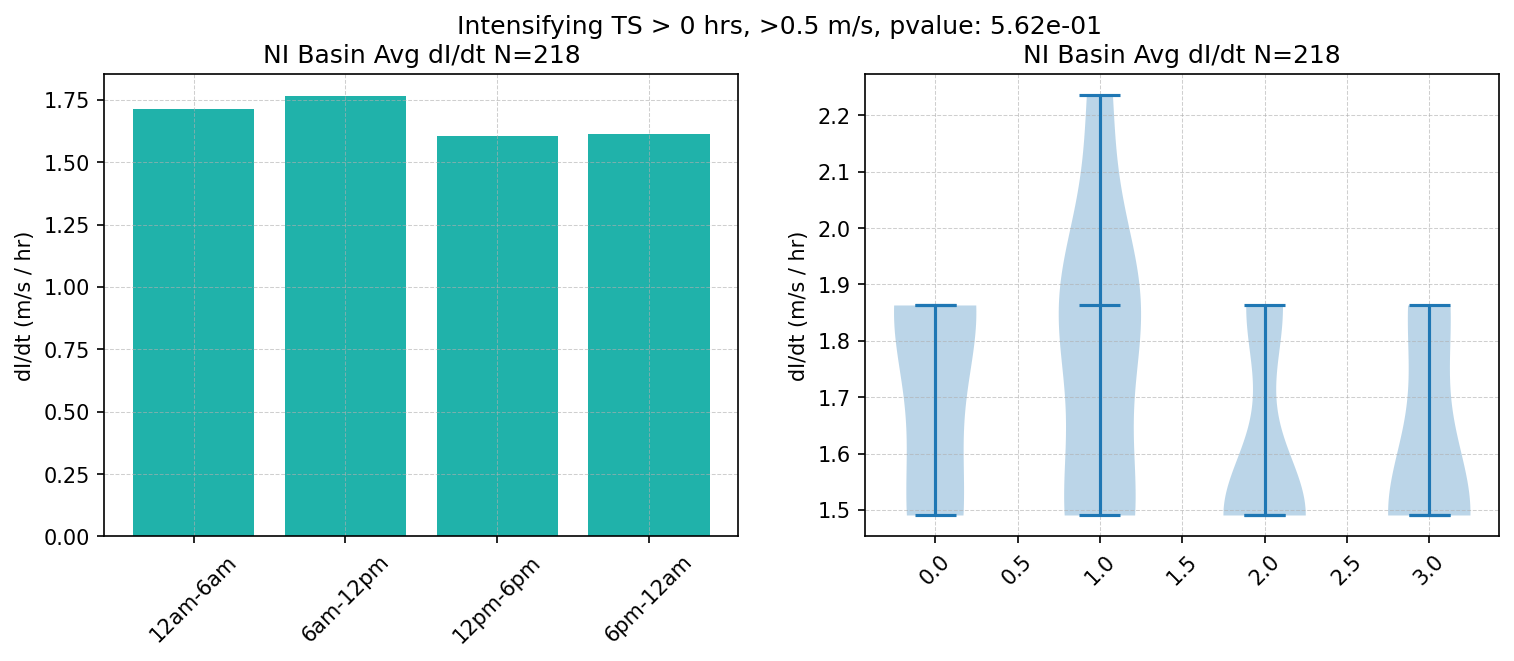

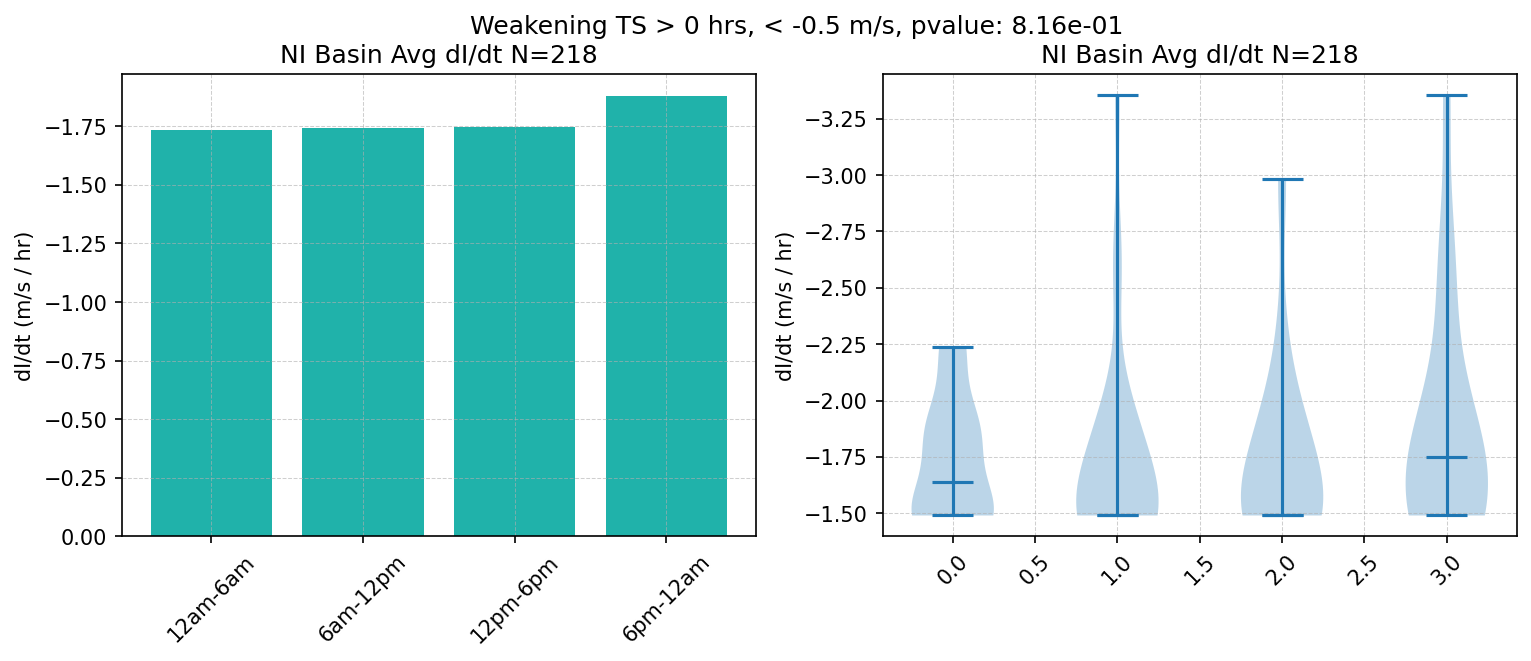

In [74]:
sindices = np.arange(2221,4787)
basin = b'NI'
nature = b'TS'
dur_thresh = 0
intensity_thresh = 0.5

inten, weak, li, lw, Ival_i, Ival_w, count =  generate_split_intensities(sindices, basin, nature, dur_thresh, intensity_thresh)

# p-value
pval_li = f"{float(ks2samp_pvalue(li, 24)):.2e}"
pval_lw = f"{float(ks2samp_pvalue(lw, 24)):.2e}"

if basin == 'all':
    subtitle = f"All Basins Avg dI/dt N={count}"
else:
    subtitle = f"{basin.decode('utf-8')} Basin Avg dI/dt N={count}"

title = f"{nature.decode('utf-8')} > {dur_thresh} hrs"


new_title = f"Intensifying {title}, >{intensity_thresh} m/s, pvalue: {pval_li}"
dIdt_hist1x2(inten, li, new_title, subtitle, 0)


new2_title = f"Weakening {title}, < -{intensity_thresh} m/s, pvalue: {pval_lw}"
dIdt_hist1x2(weak, lw, new2_title, subtitle, 1)

## max dI/dt histograms

In [42]:
sindices = np.arange(2221,4787)
basin = 'all'
nature = b'TS'
threshold = "none"
accel_type = 'max'
duration_thresh = 24

maxdIdt, maxtimes, count, intensities = generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type)

1000 / 2565 databases loaded
2000 / 2565 databases loaded


In [ ]:
num_blocks = 4

cat = get_categories(num_blocks)
hist = np.zeros(num_blocks)
    
for time in maxtimes:
    # organize genesis hour into time block
    block = sort_genesis(num_blocks, time)

    # append to histogram
    hist[block] += 1

# -------------------- Plots
fig, ax = plt.subplots(figsize=(4,4), dpi=150)
ax.bar(cat, hist, capsize=3, color='khaki')
ax.set_xlabel('LST bin')
ax.set_ylabel('Freq of max dI/dt')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

if basin == 'all':
    fig.suptitle(f"All Basins Max dI/dt Frequency N={count}")
else:
    fig.suptitle(f"{basin.decode('utf-8')} Max dI/dt Frequency N={count}")

if duration_thresh == 0:
    ax.set_title(f"{nature.decode('utf-8')} only {threshold} m/s", fontsize=9, color='gray')
else:
    ax.set_title(f"{nature.decode('utf-8')} only {threshold} m/s > {duration_thresh} hrs", fontsize=9, color='gray')

plt.setp(ax.get_xticklabels(), rotation=45)

#### grouped bar plot: max dI/dt by windspeed intensity

In [ ]:
num_blocks = 4
sindices = np.arange(2221,4787)
basin = b'SP'
nature = b'TS'
threshold = "none"
duration_thresh = 24
accel_type = 'min'

series = dict()
cat = get_categories(num_blocks)
totalcount = 0

# 17-33 m/s
hist = np.zeros(num_blocks)
maxdIdt, maxtimes, maxIvals, count = generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type)

trial = 0
for index, time in enumerate(maxtimes):
    if maxIvals[index] >= 17 and maxIvals[index] < 33:
        trial += 1
        block = sort_genesis(num_blocks, time)
        hist[block] += 1

hist = [block/(sum(hist)) for block in hist]
series['17-33'] = np.array(hist)
totalcount += trial

# >= 33 m/s
hist = np.zeros(num_blocks)
maxdIdt, maxtimes, maxIvals, count = generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type)

trial = 0
for index, time in enumerate(maxtimes):
    if maxIvals[index] >= 33:
        trial += 1
        block = sort_genesis(num_blocks, time)
        hist[block] += 1

hist = [block/(sum(hist)) for block in hist]
series['>33'] = np.array(hist)
totalcount += trial

'\n# First Intensity\nthreshold = "17-33"\nhist = np.zeros(num_blocks)\nmaxdIdt, maxtimes, count = generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type)\n\nfor time in maxtimes:\n    block = sort_genesis(num_blocks, time)\n    hist[block] += 1\n\nseries[threshold] = np.array(hist)\ntotalcount += count\n\n# Second Intensity\nthreshold = "33-1000"\nhist = np.zeros(num_blocks)\nmaxdIdt, maxtimes, count = generate_maxaccel(sindices, basin, nature, threshold, duration_thresh, accel_type)\n\nfor time in maxtimes:\n    block = sort_genesis(num_blocks, time)\n    hist[block] += 1\n\nseries[threshold] = np.array(hist)\ntotalcount += count\n'

[None, None, None, None]

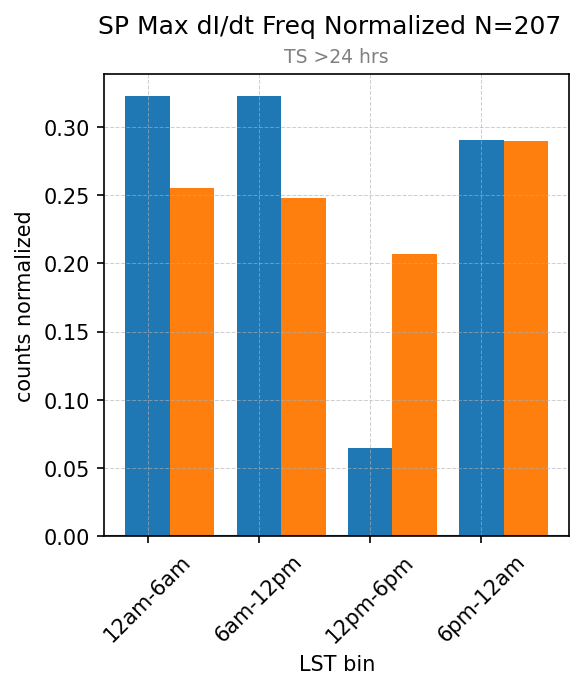

In [79]:
# ------------------------ Plot Figure ------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=150)

cat = get_categories(num_blocks)

x = np.arange(len(cat))  # the label locations
width = 0.4
multiplier = 0

for intensity in series.keys():
    offset = width * multiplier
    rects = ax.bar(x + offset, series[intensity], width, label=intensity)
    #ax.bar_label(rects, label_type='edge', fmt='%.3f', fontsize=4)
    multiplier += 1

ax.axhline(0,)
ax.set_xticks(x)
ax.set_xticklabels(cat)
ax.set_xlabel('LST bin')
ax.set_ylabel('counts normalized')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
#ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Places legend outside to the right

if basin == 'all':
    fig.suptitle(f"All Basins Max dI/dt Freq Normalized N={totalcount}")
else:
    fig.suptitle(f"{basin.decode('utf-8')} Max dI/dt Freq Normalized N={totalcount}")
ax.set_title(f"{nature.decode('utf-8')} >{duration_thresh} hrs", fontsize=9, color='gray')
#ax.set_title(f"2000-2025", fontsize=9, color='gray')

plt.setp(ax.get_xticklabels(), rotation=45)

### all basins

1000 / 4786 databases loaded
2000 / 4786 databases loaded
3000 / 4786 databases loaded
4000 / 4786 databases loaded
1000 / 1469 databases loaded


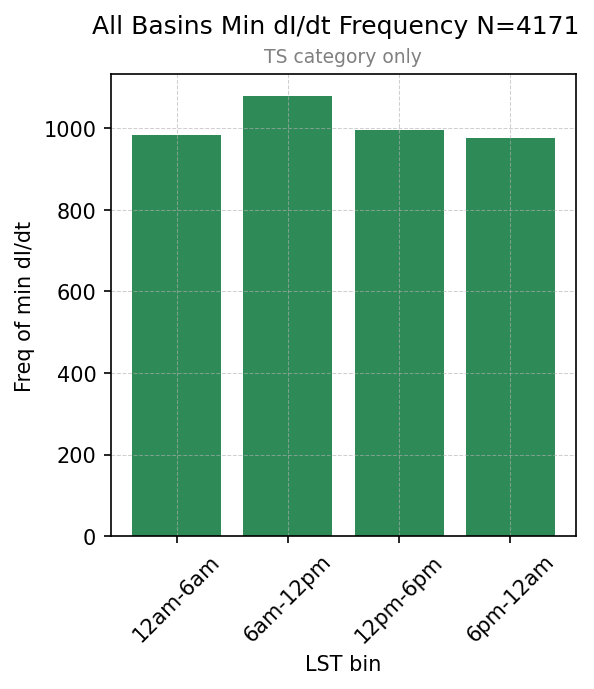

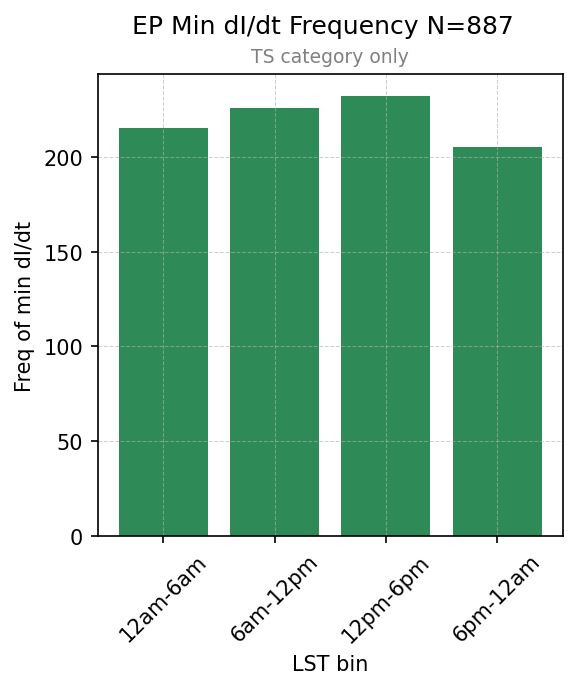

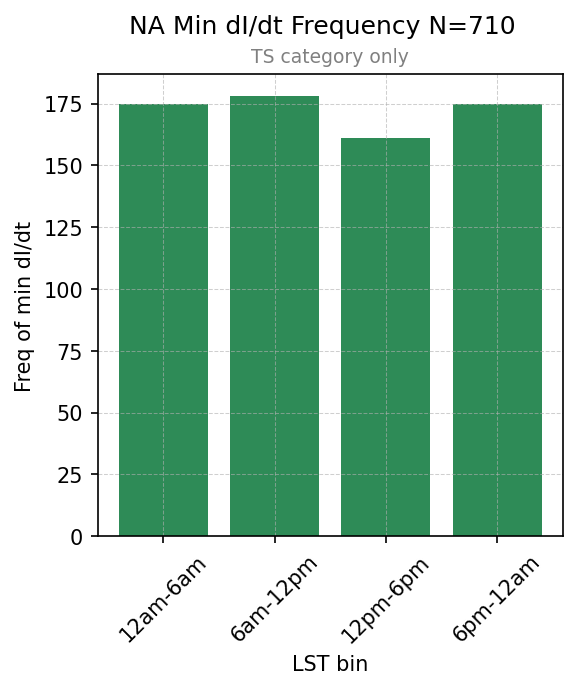

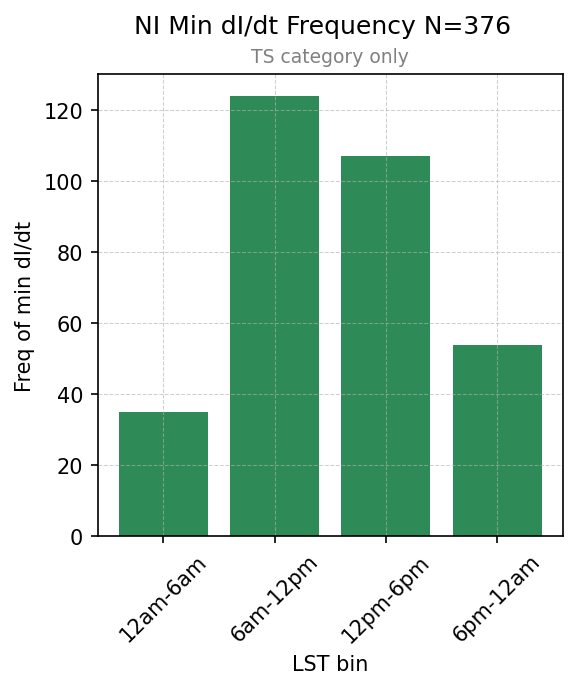

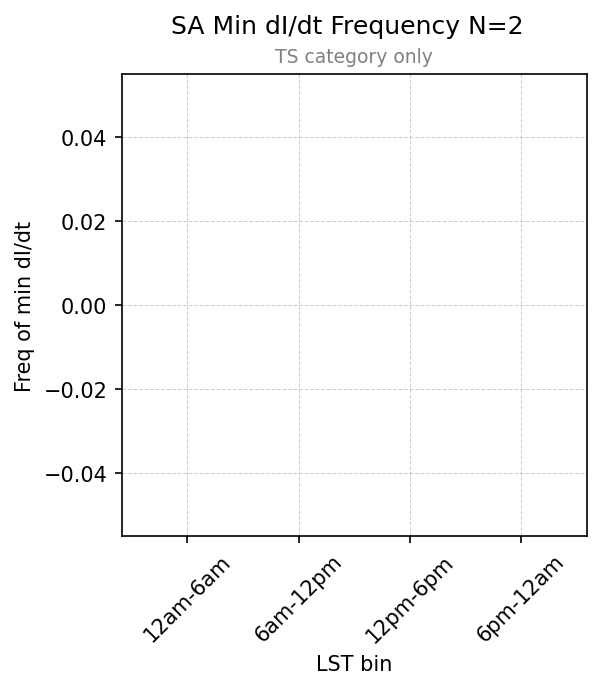

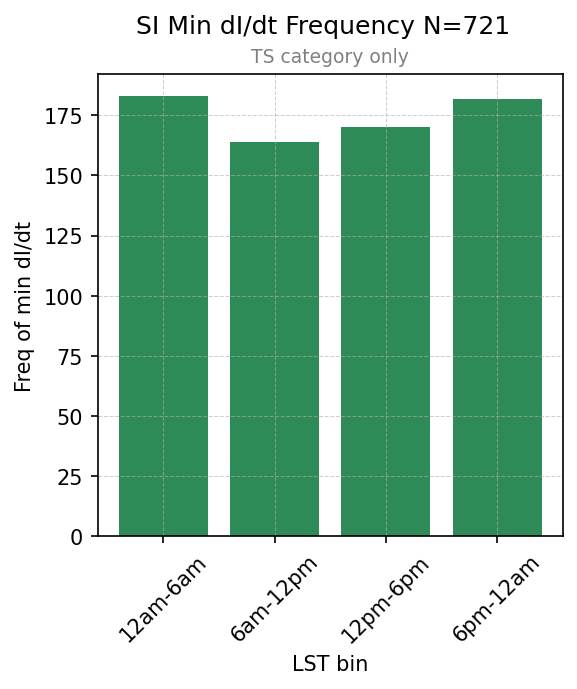

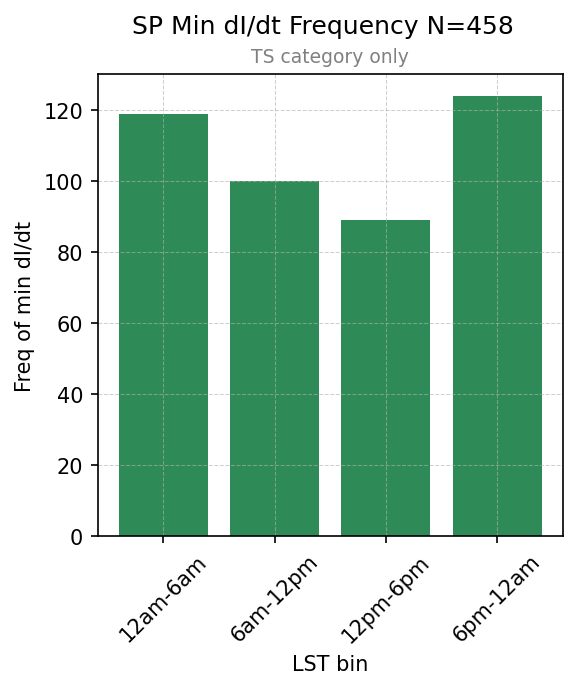

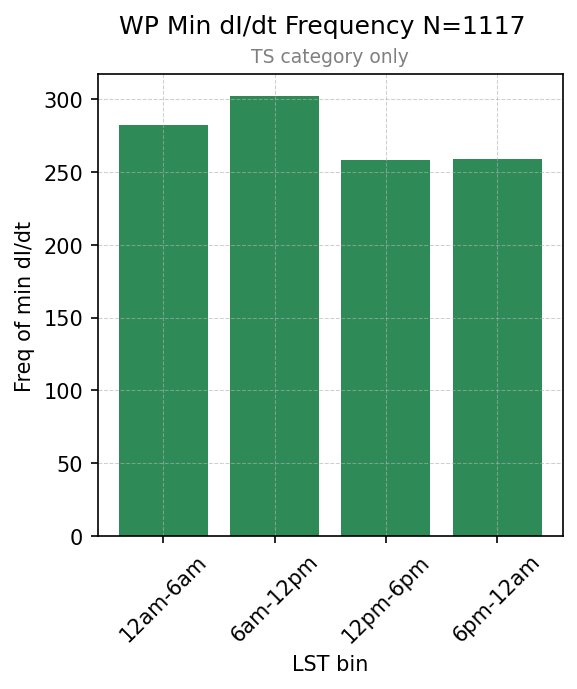

In [65]:
basins = ['all', b'EP', b'NA', b'NI', b'SA', b'SI', b'SP', b'WP']
num_blocks = 4
nature = b'TS'
accel_type = 'min'
duration_thresh = 0
cat = get_categories(num_blocks)

for basin in basins:
    sindices = np.arange(0,4787)
    
    maxdIdt, maxtimes, count = generate_maxaccel(sindices, basin, nature, duration_thresh, accel_type)

    hist = np.zeros(num_blocks)
        
    for time in maxtimes:
        # organize genesis hour into time block
        block = sort_genesis(num_blocks, time)
    
        # append to histogram
        hist[block] += 1
    
    # -------------------- Plots
    fig, ax = plt.subplots(figsize=(4,4), dpi=150)
    ax.bar(cat, hist, capsize=3, color='seagreen')
    ax.set_xlabel('LST bin')
    ax.set_ylabel('Freq of min dI/dt')
    ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    
    if basin == 'all':
        fig.suptitle(f"All Basins Min dI/dt Frequency N={count}")
    else:
        fig.suptitle(f"{basin.decode('utf-8')} Min dI/dt Frequency N={count}")
    
    if duration_thresh == 0:
        ax.set_title(f"{nature.decode('utf-8')} category only", fontsize=9, color='gray')
    else:
        ax.set_title(f"{nature.decode('utf-8')} category only - filtered > {duration_thresh} hrs", fontsize=9, color='gray')
    
    plt.setp(ax.get_xticklabels(), rotation=45)

# local maxes dI/dt

In [51]:
num_blocks = 4
sindices = np.arange(2221,4787)
basin = b'SI'
nature = b'TS'
duration_thresh = 48

series = dict()
cat = get_categories(num_blocks)
pos = np.arange(num_blocks)

# generate dI/dt values
maxdIdt, maxtimes, maxIvals, count = generate_localmaxes(sindices, basin, nature, "none", duration_thresh, "max")

# create df of dIdt data
dIdts = []
times = []
LSTs = []
Iclass = []
Is = []

# counts
midcount = 0
hicount = 0

#------------------------ Group maxdIdt values -----------------------------
for index, time in enumerate(maxtimes):
    I = maxIvals[index]
    if I >= 17:
        block = sort_genesis(num_blocks, time)
        
        dIdts.append(maxdIdt[index])
        times.append(time)
        LSTs.append(block)
        Is.append(I)
        if I < 33:
            midcount += 1
            Iclass.append('17-33')
        elif I >= 33:
            hicount += 1
            Iclass.append('>33')

dIdt_df = pd.DataFrame({'dIdt': dIdts, 'I values': Is, 'ltimes': times, 'LST': LSTs, 'intensities': Iclass})

## Violin plots

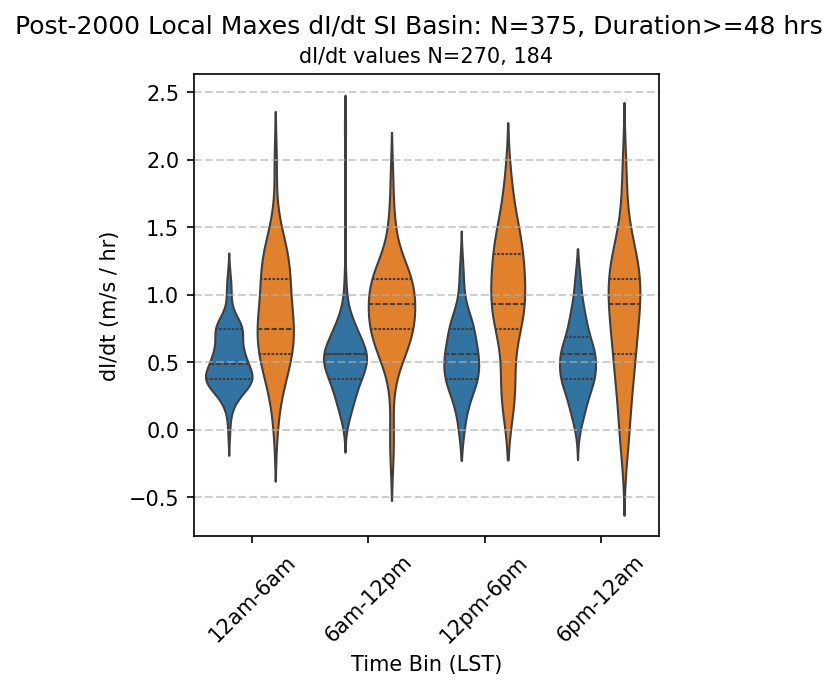

In [52]:
#------------------------ Max dI/dt Grouped Violin Plot -----------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=150)

ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='dIdt', hue='intensities',
               ax=ax, linewidth=1, hue_order=["17-33", ">33"], legend=False)
ax.set_title(f"dI/dt values N={midcount}, {hicount}", fontsize=10)

if basin == "all":
    fig.suptitle(f"Post-2000 Local Maxes dI/dt All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Local Maxes dI/dt {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

## Avg histogram std error bars

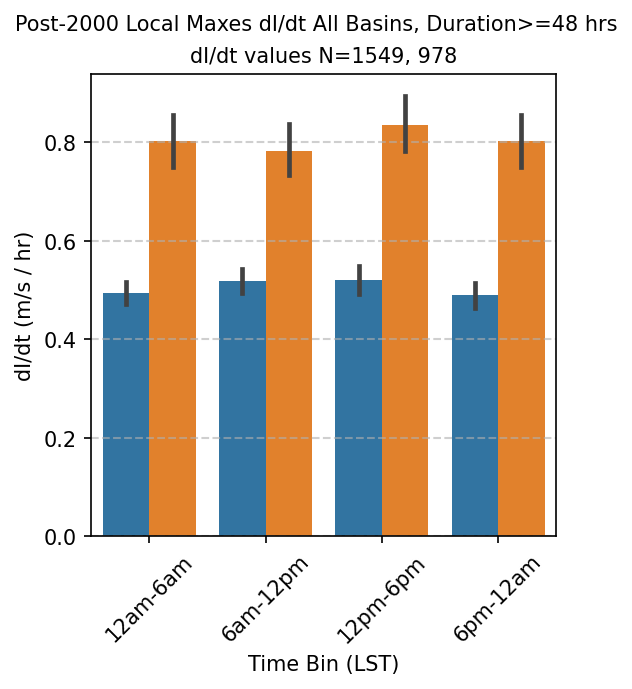

In [30]:
#------------------------ Max dI/dt Grouped Histogram -----------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=150)

ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

sns.barplot(data=dIdt_df, x='LST', y='dIdt', hue='intensities',
               ax=ax, linewidth=1, hue_order=["17-33", ">33"], legend=False)
ax.set_title(f"dI/dt values N={midcount}, {hicount}", fontsize=10)

if basin == "all":
    fig.suptitle(f"Post-2000 Local Maxes dI/dt All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Local Maxes dI/dt {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

## Local max (17-33) dI/dt TS decomposed
For each storm
1. Split all dI/dt values into 2 segments (those between 17-33 m/s and >33 m/s)
    * Weakened dI/dt values after high intensity category were excluded
    * Sometimes 2nd segment doesn’t exist
2. Find local max of dI/dt within each segment
    * Add those dI/dt values to distribution
3. **Break down distribution into 4 TS sub-categories**
4. Plot violin plot

In [141]:
num_blocks = 4
sindices = np.arange(2221,4787)
basin = 'all'
nature = b'TS'
duration_thresh = 0

series = dict()
cat = get_categories(num_blocks)
pos = np.arange(num_blocks)

# generate dI/dt values
maxdIdt, maxtimes, maxIvals, count = generate_localmaxes(sindices, basin, nature, "none", duration_thresh, "max", "default")

# create df of dIdt data
dIdts = []
times = []
LSTs = []
Iclass = []
Is = []

# counts
counts = np.zeros(4)

#------------------------ Group maxdIdt values -----------------------------
for index, time in enumerate(maxtimes):
    I = maxIvals[index]
    if I >= 17 and I < 33:
        block = sort_genesis(num_blocks, time)
        
        dIdts.append(maxdIdt[index])
        times.append(time)
        LSTs.append(block)
        Is.append(I)
        if I >= 17 and I < 21:
            counts[0] += 1
            Iclass.append('[17,21)')
        elif I >= 21 and I < 25:
            counts[1] += 1
            Iclass.append('[21,25)')
        elif I >= 25 and I < 29:
            counts[2] += 1
            Iclass.append('[25,29)')
        elif I >= 29 and I < 33:
            counts[3] += 1
            Iclass.append('[29,33)')

dIdt_df = pd.DataFrame({'dIdt': dIdts, 'I values': Is, 'ltimes': times, 'LST': LSTs, 'intensities': Iclass})

1000 / 2565 databases loaded
2000 / 2565 databases loaded


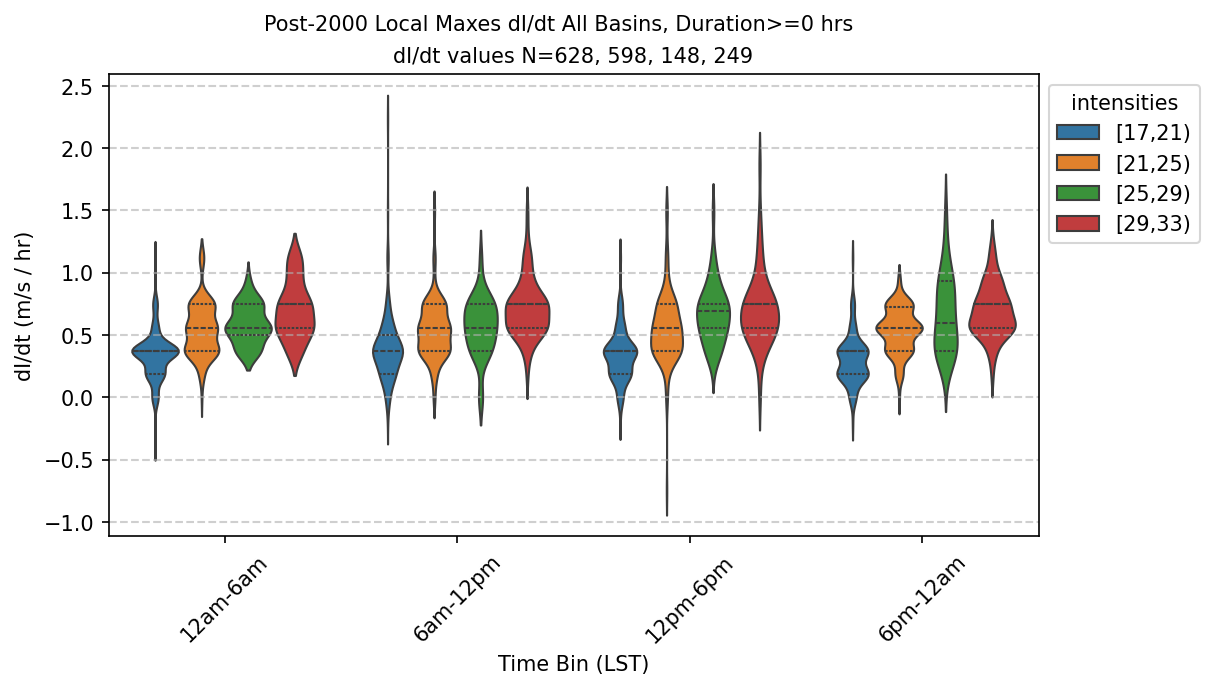

In [142]:
#------------------------ Max dI/dt Grouped Violin Plot -----------------------------
fig, ax = plt.subplots(figsize=(8,4), dpi=150)

ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='dIdt', hue='intensities',
               ax=ax, linewidth=1, hue_order=["[17,21)", "[21,25)", "[25,29)", "[29,33)"])
ax.set_title(f"dI/dt values N={int(counts[0])}, {int(counts[1])}, {int(counts[2])}, {int(counts[3])}", fontsize=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

if basin == "all":
    fig.suptitle(f"Post-2000 Local Maxes dI/dt All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Local Maxes dI/dt {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")

## Local max dI/dt TS decomposed

In [153]:
num_blocks = 4
sindices = np.arange(2221,4787)
basin = 'all'
nature = b'TS'
duration_thresh = 0
segment_threshs = "17,21,25,29,33"

series = dict()
cat = get_categories(num_blocks)
pos = np.arange(num_blocks)

# generate dI/dt values
maxdIdt, maxtimes, maxIvals, count = generate_localmaxes(sindices, basin, nature, "none", duration_thresh, "max", segment_threshs)

# create df of dIdt data
dIdts = []
times = []
LSTs = []
Iclass = []
Is = []

# counts
counts = np.zeros(4)

#------------------------ Group maxdIdt values -----------------------------
for index, time in enumerate(maxtimes):
    I = maxIvals[index]
    if I >= 17 and I < 33:
        block = sort_genesis(num_blocks, time)
        
        dIdts.append(maxdIdt[index])
        times.append(time)
        LSTs.append(block)
        Is.append(I)
        if I >= 17 and I < 21:
            counts[0] += 1
            Iclass.append('[17,21)')
        elif I >= 21 and I < 25:
            counts[1] += 1
            Iclass.append('[21,25)')
        elif I >= 25 and I < 29:
            counts[2] += 1
            Iclass.append('[25,29)')
        elif I >= 29 and I < 33:
            counts[3] += 1
            Iclass.append('[29,33)')

dIdt_df = pd.DataFrame({'dIdt': dIdts, 'I values': Is, 'ltimes': times, 'LST': LSTs, 'intensities': Iclass})

1000 / 2565 databases loaded
2000 / 2565 databases loaded


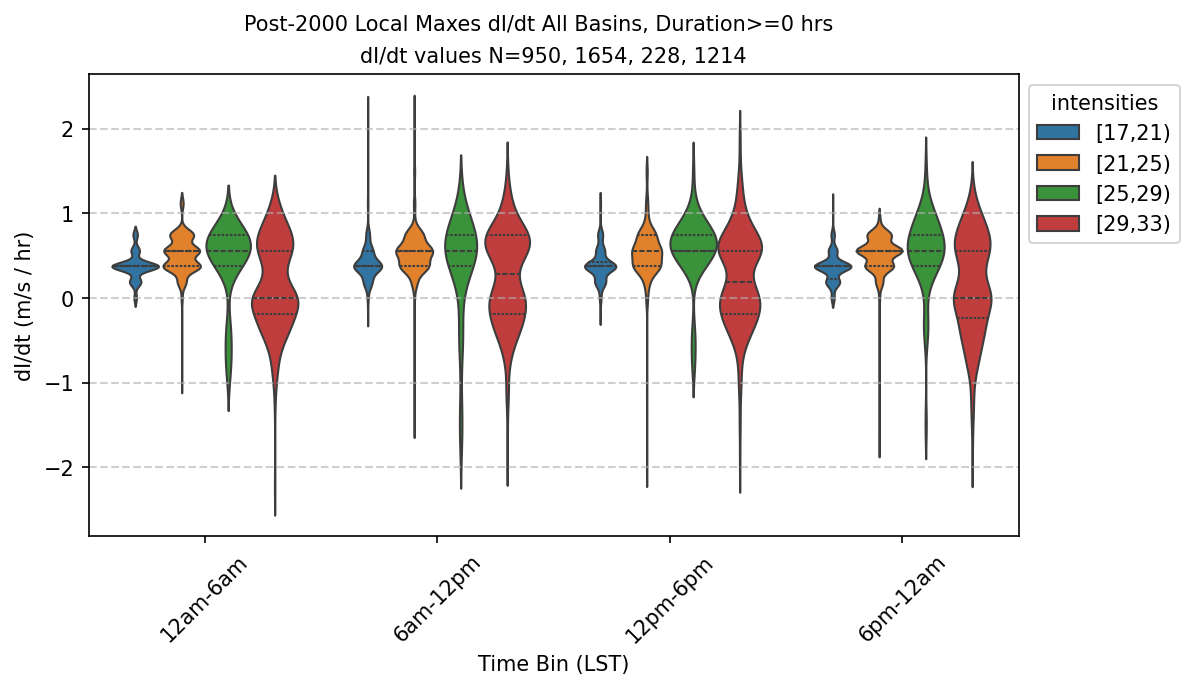

In [154]:
#------------------------ Max dI/dt Grouped Violin Plot -----------------------------
fig, ax = plt.subplots(figsize=(8,4), dpi=150)

ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

sns.violinplot(data=dIdt_df, inner='quart', x='LST', y='dIdt', hue='intensities',
               ax=ax, linewidth=1, hue_order=["[17,21)", "[21,25)", "[25,29)", "[29,33)"])
ax.set_title(f"dI/dt values N={int(counts[0])}, {int(counts[1])}, {int(counts[2])}, {int(counts[3])}", fontsize=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

if basin == "all":
    fig.suptitle(f"Post-2000 Local Maxes dI/dt All Basins, Duration>={duration_thresh} hrs", fontsize=10)
else:
    fig.suptitle(f"Post-2000 Local Maxes dI/dt {basin.decode('utf-8')} Basin: N={count}, Duration>={duration_thresh} hrs")